# Practice: Ridge, Lasso & ElasticNet Regularization

**MSDS 640 — Hands-On Challenge**

In this practice you will:
1. Build a linear regression model that **overfits** (using polynomial features)
2. Apply **Ridge (L2)** regularization to reduce overfitting
3. Apply **Lasso (L1)** regularization to reduce overfitting AND perform feature selection
4. Apply **ElasticNet** (combined L1+L2) to get the best of both worlds
5. Compare all models and draw conclusions

---

---
## Git Quick Reference: Pushing This Notebook to GitHub

Use these commands in your **terminal** (not in Python) to push your work to GitHub.

### First-Time Setup (do once)
```bash
# Configure your identity
git config --global user.name "Your Name"
git config --global user.email "your@email.com"

# Create a repository folder and initialize
mkdir MSDS640-coursework
cd MSDS640-coursework
git init

# Connect to your GitHub repo (replace with YOUR URL)
git remote add origin git@github.com:YOUR_USERNAME/MSDS640-coursework.git
```

### Push Your Work (do after every session)
```bash
# Check what files have changed
git status

# Stage files for commit
git add Session1_Ridge_Lasso_Practice.ipynb

# Save a snapshot with a message describing what you did
git commit -m "Complete Week 1 Ridge/Lasso practice"

# Upload to GitHub
git push -u origin main
```

### Pull Updates (get code from GitHub)
```bash
# Download and merge latest changes
git pull origin main
```

### Essential Commands Cheat Sheet

| Command | What It Does |
|---------|-------------|
| `git init` | Initialize a new local repository |
| `git clone <url>` | Download an existing repo from GitHub |
| `git status` | See which files are modified/staged |
| `git add <file>` | Stage a file for the next commit |
| `git commit -m "msg"` | Save a snapshot with a description |
| `git push` | Upload commits to GitHub |
| `git pull` | Download and merge from GitHub |
| `git log --oneline` | View commit history (compact) |
| `git diff` | See what changed since last commit |

**Assignment:** Keep a record of every command you run and what it does!

---

## Background: The Regularization Framework

### The General Regression Problem

In **Ordinary Least Squares (OLS)**, we minimize the residual sum of squares:

$$\hat{w} = \arg\min_w \; \underbrace{\sum_{i=1}^n (y_i - w^T x_i)^2}_{\text{RSS — Residual Sum of Squares}}$$

This finds the best fit to training data, but with many features it can **overfit** — the model fits noise in the training data and performs poorly on new data.

### The Regularized Version (General Form)

Regularization adds a **penalty term** that constrains the coefficients:

$$\hat{w} = \arg\min_w \; \underbrace{\sum_{i=1}^n (y_i - w^T x_i)^2}_{\text{Data fit (RSS)}} + \underbrace{\lambda \cdot \Omega(w)}_{\text{Penalty (regularizer)}}$$

Where $\Omega(w)$ is the regularization function and $\lambda$ (called `alpha` in sklearn) controls the strength.

---

### Ridge Regression (L2 Regularization)

$$\hat{w}_{\text{Ridge}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \sum_{j=1}^p w_j^2$$

**Penalty:** $\|w\|_2^2 = w_1^2 + w_2^2 + \ldots + w_p^2$ (squared L2 norm)

**Closed-form solution:** $\hat{w} = (X^T X + \alpha I)^{-1} X^T y$

**Effect:** Shrinks ALL coefficients toward zero, but never exactly to zero.

---

### Lasso Regression (L1 Regularization)

$$\hat{w}_{\text{Lasso}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \sum_{j=1}^p |w_j|$$

**Penalty:** $\|w\|_1 = |w_1| + |w_2| + \ldots + |w_p|$ (L1 norm)

**No closed-form** — solved iteratively (coordinate descent).

**Effect:** Shrinks coefficients AND can set some exactly to zero → automatic feature selection.

---

### ElasticNet (L1 + L2 Combined)

$$\hat{w}_{\text{EN}} = \arg\min_w \; \sum_{i=1}^n (y_i - w^T x_i)^2 + \alpha \left[ \rho \sum_{j=1}^p |w_j| + \frac{(1-\rho)}{2} \sum_{j=1}^p w_j^2 \right]$$

**Parameters:**
- $\alpha$ = overall regularization strength (`alpha` in sklearn)
- $\rho$ = mixing ratio between L1 and L2 (`l1_ratio` in sklearn)
  - $\rho = 1$ → pure Lasso
  - $\rho = 0$ → pure Ridge
  - $0 < \rho < 1$ → blend of both

**Effect:** Performs feature selection (like Lasso) while handling correlated features stably (like Ridge).

---

### Summary Table

| Method | Penalty $\Omega(w)$ | Sparsity? | Handles Correlation? | # Hyperparams |
|--------|--------------------:|:---------:|:-------------------:|:-------------:|
| OLS | None | No | No | 0 |
| Ridge | $\sum w_j^2$ | No | Yes | 1 ($\alpha$) |
| Lasso | $\sum \|w_j\|$ | Yes | No | 1 ($\alpha$) |
| ElasticNet | $\rho\sum\|w_j\| + \frac{1-\rho}{2}\sum w_j^2$ | Yes | Yes | 2 ($\alpha$, $\rho$) |

---
## Setup: Imports

All the libraries you will need are imported below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
import sys
!{sys.executable} -m pip install xgboost

In [3]:
from xgboost import XGBRegressor

---
## Part 1: Load and Explore the Data

We will use the **California Housing** dataset (a modern replacement for Boston Housing).

**Your tasks:**
1. Load the dataset using `fetch_california_housing()`
2. Create a DataFrame with the feature names as columns
3. Print the shape, first 5 rows, and `.describe()` statistics

**Functions to use:**
- `fetch_california_housing()` — returns object with `.data`, `.target`, `.feature_names`, `.DESCR`
- `pd.DataFrame(data, columns=...)` — create a DataFrame
- `.shape`, `.head()`, `.describe()` — DataFrame inspection methods

In [4]:
housing = fetch_california_housing()
X = housing.data
y = housing.target
feature_names = housing.feature_names

print("Dataset description:")
print(housing.DESCR)

df = pd.DataFrame(X, columns=feature_names)
df['MedHouseVal'] = y # Add target to DataFrame for full description

print(f"\nDataset shape: {df.shape}")
print("\nFirst 5 rows of the dataset:")
display(df.head())

print("\nDescriptive statistics:")
display(df.describe())

Dataset description:
.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census,

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



Descriptive statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Dataset Characteristics:

Based on the output of that cell, here are the key characteristics of the California Housing dataset:

Size & structure: 20,640 rows (each a census block group from the 1990 U.S. census) with 8 predictive features plus the target — 9 columns total. All values are numeric and there are no missing values.

Target variable (MedHouseVal): median house value in units of 100,000 US Dollars. It's capped at 5.0 (i.e., $500,001), shown by the max of exactly 5.00001 — this ceiling censoring is a known quirk of the dataset.

MedInc is also capped at ~15.0001, another artificial ceiling worth being aware of.

Features live on very different scales: MedInc runs ~0.5–15, HouseAge 1–52, Population 3–35,682, Latitude/Longitude in the 30s/-110s. This matters directly for your Ridge/Lasso work — the L1/L2 penalties are scale-sensitive, so standardizing (StandardScaler) before regularizing is essential, otherwise features with larger magnitudes get penalized unfairly.

Heavy right skew and outliers in several columns. Look at the gap between the median and max: AveRooms (median 5.2 vs max 141.9), AveBedrms (1.05 vs 34.1), and AveOccup (2.8 vs 1243).

The DESCR explains why — these are per-household averages, so block groups with few households and many empty homes (e.g., vacation areas) produce extreme values.

Geographic component: Latitude and Longitude are included, so spatial location is a predictor — relevant since California house prices are strongly location-driven.

Ranges are tight and interpretable: HouseAge maxes out at 52 years (also capped), and the coordinates confirm the data is confined to California.

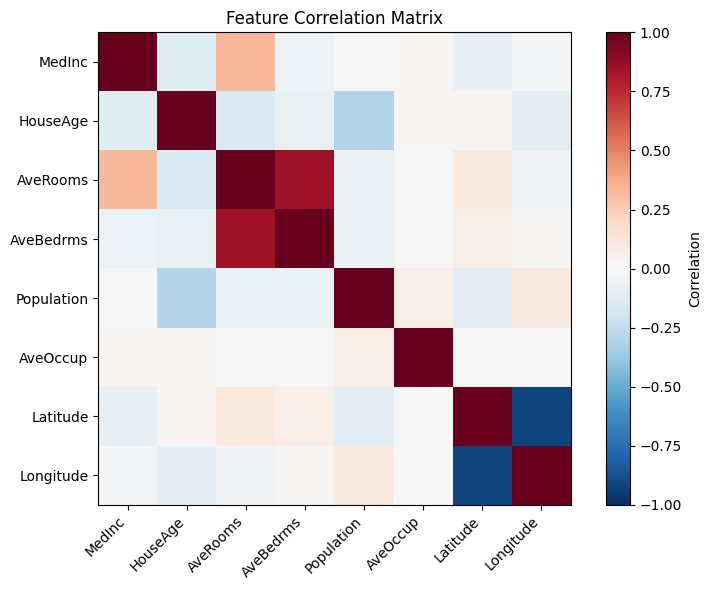

In [5]:
df_features = pd.DataFrame(X, columns=feature_names)
corr = df_features.corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

Strongest positive correlations:

AveRooms ↔ AveBedrms (r ≈ 0.85): more rooms per household tracks with more bedrooms — largely redundant information.

MedInc ↔ AveRooms (r ≈ 0.33): wealthier block groups tend to have larger homes, though the link is only moderate.

Strongest negative correlations:

Latitude ↔ Longitude (r ≈ −0.92): the strongest relationship in the whole matrix by magnitude — but it's a geographic artifact of California's diagonal shape, not anything about housing.

AveOccup ↔ small/weak negatives elsewhere: nothing else stands out; most remaining pairs are near zero.

Why this is significant for this data:

Multicollinearity destabilizes linear models. When features carry overlapping information (the two pairs above), plain OLS coefficients become large, unstable, and hard to interpret — small data changes swing them wildly.

This is the core motivation for your Ridge/Lasso exercise. Ridge (L2) shrinks correlated coefficients together, spreading the weight across the pair; Lasso (L1) tends to pick one and zero out the other — so watch for AveBedrms getting dropped while AveRooms stays.

Redundant features add variance without adding signal, which is exactly what regularization is designed to control — a clean, concrete example to cite in your writeup.

The Latitude/Longitude pair is a caution flag: it's strong but not causally meaningful, a good reminder that high correlation ≠ useful predictor, and that location is better captured jointly than by either coordinate alone.

---
## Part 2: Train/Test Split and Baseline Model

**Your tasks:**
1. Split the data: 80% train, 20% test (use `random_state=42`)
2. Train a plain `LinearRegression()` on the raw features
3. Compute RMSE and R² on both train and test sets

**Functions to use:**
- `train_test_split(X, y, test_size=0.2, random_state=42)` — splits data
- `LinearRegression()` — creates model; `.fit(X, y)` trains it; `.predict(X)` gets predictions
- `mean_squared_error(y_true, y_pred)` — computes MSE; wrap in `np.sqrt()` for RMSE
- `r2_score(y_true, y_pred)` — computes R² (coefficient of determination)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

p_train = linreg.predict(X_train)
p_test = linreg.predict(X_test)

rmse_train_baseline = np.sqrt(mean_squared_error(y_train, p_train))
rmse_test_baseline = np.sqrt(mean_squared_error(y_test, p_test))
r2_train_baseline = r2_score(y_train, p_train)
r2_test_baseline = r2_score(y_test, p_test)

print("Baseline Linear Regression (raw features):")
print(f"  Train RMSE: {rmse_train_baseline:.4f}, R²: {r2_train_baseline:.4f}")
print(f"  Test  RMSE: {rmse_test_baseline:.4f}, R²: {r2_test_baseline:.4f}")

Baseline Linear Regression (raw features):
  Train RMSE: 0.7197, R²: 0.6126
  Test  RMSE: 0.7456, R²: 0.5758



What the metrics mean in context:

R² ≈ 0.58–0.61: the model explains roughly 58% of the variance in median house value on unseen data. That's moderate — clearly better than nothing, but leaving ~40% of the variation unexplained.

RMSE ≈ 0.75: since the target is in units of 100,000 US Dollars, your typical prediction is off by about 75,000 US Dollars. Whether that's "good" depends on the use case, but it's a sizable error.

Sanity check against a naive baseline: the target's standard deviation is ~1.15, which is what RMSE would be if you just predicted the mean every time. Your 0.75 beats that comfortably, so the features are genuinely carrying signal.

Overfitting or underfitting?

Not overfitting. Train and test are very close (RMSE 0.72 vs 0.75; R² 0.61 vs 0.58). The tiny train→test gap means the model generalizes fine — it isn't memorizing the training set.

If anything, it's mildly underfitting (high bias). The performance ceiling is modest on both splits, which says the model is too simple to capture the real structure — plain linear regression can't represent nonlinear effects (e.g., income's curved relationship with price) or the geographic interaction between Latitude and Longitude.

Why this matters for the exercise:

This baseline is doing its job: it's a clean, non-overfit reference point that underfits slightly.

The next step — adding polynomial features — deliberately increases model capacity, which will raise train performance but likely open up a train→test gap (overfitting). That's the problem Ridge/Lasso/ElasticNet then exist to fix.

So the story arc is: underfit (here) → overfit (polynomial) → regularize back to a good balance. Keep these baseline numbers handy; every later model gets compared against them.

---
## Part 3: Create an Overfitting Scenario with Polynomial Features

Now we'll engineer a situation where regularization clearly helps. By adding **polynomial features** (degree=2), we create many more parameters than needed — the model will overfit.

**Your tasks:**
1. Expand features using `PolynomialFeatures(degree=2, include_bias=False)`
2. Scale the expanded features with `StandardScaler`
3. Train `LinearRegression()` on the polynomial features
4. Compute RMSE on train and test — observe the overfitting gap!

**Functions to use:**
- `PolynomialFeatures(degree=2, include_bias=False)` — creates polynomial/interaction features
  - `.fit_transform(X_train)` — fit on train AND transform
  - `.transform(X_test)` — transform test using same expansion (never fit on test!)
- `StandardScaler()` — standardizes features to mean=0, std=1
  - `.fit_transform(X_train)` — fit on train AND transform
  - `.transform(X_test)` — apply same scaling to test
- Check `X_train_poly.shape[1]` to see how many features you created

In [7]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print(f"Original features: {X_train.shape[1]}")
print(f"Polynomial features: {X_train_poly.shape[1]}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

linreg_poly = LinearRegression()
linreg_poly.fit(X_train_scaled, y_train)

rmse_train_poly = np.sqrt(mean_squared_error(y_train, linreg_poly.predict(X_train_scaled)))
rmse_test_poly = np.sqrt(mean_squared_error(y_test, linreg_poly.predict(X_test_scaled)))

print("Linear Regression with Polynomial Features (degree=2):")
print(f"  Train RMSE: {rmse_train_poly:.4f}")
print(f"  Test  RMSE: {rmse_test_poly:.4f}")
print(f"  Gap (overfitting): {rmse_test_poly - rmse_train_poly:.4f}")

Original features: 8
Polynomial features: 44
Linear Regression with Polynomial Features (degree=2):
  Train RMSE: 0.6486
  Test  RMSE: 0.6814
  Gap (overfitting): 0.0328


**Question:** How many features does degree=2 polynomial expansion create from 8 original features? Why does this lead to overfitting?

*Your answer:*

The Degree-2 polynomial expansion transforms the 8 original features into 44 total features with 8 original terms, 8 squared terms, and 28 pairwise interactions. This jump in dimensionality causes overfitting primarily by giving the model a lot more freedom and less restriction, it starts to chase noise in the training set that don't generalize, causing training error to drop while test error stagnates or rises. The problem is also exacerbated by collinearity, since each squared and interaction term is strongly correlated with the features that generate it, inflating coefficient variance and producing large, unstable coefficients.

The dataset's characteristics make this even worse because features like AveRooms and AveOccup contain extreme outliers, and squaring them creates enormous, outlier-dominated values that add more instability. This is why the StandardScaler step is essential. The net effect is a widening gap between training and test RMSE, as the model memorizes the training data rather than learning generalizable structure. This is exactly the problem Ridge and Lasso regularization are designed to fix.





---
## Part 4: Ridge Regression (L2 Regularization)

### Formula Reminder

$$\text{Loss}_{\text{Ridge}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p w_j^2$$

The penalty discourages large coefficients. As $\alpha$ increases, coefficients shrink more.

**Your tasks:**
1. Study the worked example below (single alpha)
2. Extend it to loop over multiple alpha values: `[0.001, 0.01, 0.1, 1.0, 10.0, 100.0]`
3. Find the alpha that gives the best test RMSE

**Functions to use:**
- `Ridge(alpha=1.0)` — creates a Ridge model
  - `.fit(X_train, y_train)` — train the model
  - `.predict(X_test)` — get predictions
  - `.coef_` — access the learned coefficients (after fitting)
- Store results in lists for plotting: `ridge_train_rmses = []`, `ridge_test_rmses = []`

**⚠️ Important:** Why does Ridge have `max_iter` optional but Lasso requires it? Because Ridge has a **closed-form solution** $(X^TX + \alpha I)^{-1}X^Ty$ — it doesn't iterate. Lasso uses coordinate descent (iterative).

In [8]:
# ============================================================
# WORKED EXAMPLE: Training Ridge with a SINGLE alpha value
# Study this pattern — you'll extend it to multiple alphas below
# ============================================================

# Step 1: Create the model with a specific alpha
ridge_example = Ridge(alpha=1.0)

# Step 2: Fit on training data
ridge_example.fit(X_train_scaled, y_train)

# Step 3: Get predictions on both sets
pred_train = ridge_example.predict(X_train_scaled)
pred_test = ridge_example.predict(X_test_scaled)

# Step 4: Compute RMSE for both sets
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

# Step 5: Report results
print(f"Ridge (alpha=1.0):")
print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")
print(f"  Coefficients: max={np.max(np.abs(ridge_example.coef_)):.3f}, min={np.min(np.abs(ridge_example.coef_)):.6f}")

Ridge (alpha=1.0):
  Train RMSE: 0.6648
  Test  RMSE: 0.6877
  Gap:        0.0229
  Coefficients: max=5.270, min=0.046222


Using Ridge regularization with alpha = 1:

Test RMSE dropped to 0.6877, down from the unregularized polynomial model — regularization improved generalization, and it also beats your original baseline (~0.75). Predictions are now off by ~$68,800 on average.

The overfitting gap is tiny (0.0229). Train and test are very close, so Ridge successfully closed the train→test gap that the polynomial expansion opened up.

Coefficients are tamed. Max absolute coefficient is 5.27 — Ridge shrank the large, unstable coefficients from the collinear polynomial terms, which is exactly the mechanism reducing the overfitting.

No coefficient is exactly zero (min ≈ 0.046, small but nonzero). This is the signature of Ridge (L2): it shrinks coefficients toward zero but never eliminates them — so all 44 features are still in the model. That's the key contrast with Lasso, which you'll see zero features out entirely.

Overall: a well-behaved model — better test accuracy than baseline and minimal overfitting. Ridge did its job of trading a little training fit for stability.

In [9]:
# try a range of alpha values
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

# lists to save the train and test error for each alpha
ridge_train_rmses = []
ridge_test_rmses = []

# print a header for the results table
print(f"{'Alpha':>10s} {'Train RMSE':>12s} {'Test RMSE':>12s} {'Gap':>10s}")
print("-" * 48)

# loop over each alpha, train a Ridge model, and record how it did
for alpha in alphas:
    ridge = Ridge(alpha=alpha)          # make the model with this alpha
    ridge.fit(X_train_scaled, y_train)  # train it

    # predict on train and test, then get the RMSE of each
    pred_train = ridge.predict(X_train_scaled)
    pred_test = ridge.predict(X_test_scaled)
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

    # save the errors so we can compare and plot them later
    ridge_train_rmses.append(rmse_train)
    ridge_test_rmses.append(rmse_test)
    print(f"{alpha:10.3f} {rmse_train:12.4f} {rmse_test:12.4f} {rmse_test - rmse_train:10.4f}")

# find the alpha with the lowest test RMSE (that's the best one)
best_idx_ridge = np.argmin(ridge_test_rmses)
best_ridge_alpha = alphas[best_idx_ridge]
best_ridge_rmse = ridge_test_rmses[best_idx_ridge]

# retrain a Ridge model with the best alpha and keep it for later
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train_scaled, y_train)
print(f"\nBest Ridge: alpha={best_ridge_alpha}")
print(f"  Test RMSE: {best_ridge_rmse:.4f}")

     Alpha   Train RMSE    Test RMSE        Gap
------------------------------------------------
     0.001       0.6486       0.6777     0.0291
     0.010       0.6492       0.6610     0.0118
     0.100       0.6540       0.6675     0.0136
     1.000       0.6648       0.6877     0.0229
    10.000       0.6770       0.7064     0.0294
   100.000       0.6922       0.7133     0.0212

Best Ridge: alpha=0.01
  Test RMSE: 0.6610


Best alpha is 0.01 (Test RMSE = 0.6610), your strongest linear model so far — beats both the alpha=1.0 example (0.6877) and the raw baseline (~0.75).

As alpha increases past 0.01, test RMSE steadily rises (0.6610 → 0.6675 → 0.6877 → 0.7064 → 0.7133). Stronger penalties over-shrink the coefficients here, pushing the model toward underfitting — exactly the "both train and test RMSE rise at alpha=100" behavior the comment predicted.

The very smallest alpha (0.001) isn't best either. Its gap (0.0291) is the widest of the low-alpha runs — too little penalty lets a bit of overfitting creep back. So 0.01 sits in the sweet spot: enough regularization to close the gap (0.0118, the smallest here), not so much that it hurts fit.

The overall effect is gentle. Test RMSE only moves ~0.05 across the whole alpha range — this polynomial feature set isn't wildly overfit to begin with, so Ridge is fine-tuning rather than rescuing a broken model.

---
## Part 5: Lasso Regression (L1 Regularization)

### Formula Reminder

$$\text{Loss}_{\text{Lasso}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \sum_{j=1}^p |w_j|$$

The L1 penalty can drive coefficients to **exactly zero** — performing automatic feature selection.

**Your tasks:**
1. Study the worked example below (single alpha)
2. Extend it to loop over multiple alpha values: `[0.001, 0.01, 0.05, 0.1, 0.5, 1.0]`
3. Track how many coefficients are exactly zero for each alpha
4. Find the best alpha

**Functions to use:**
- `Lasso(alpha=1.0, max_iter=10000)` — creates a Lasso model
  - Set `max_iter=10000` to ensure the iterative solver converges
  - `.coef_` — the coefficient array (check which are zero!)
- `np.sum(model.coef_ == 0)` — count how many coefficients are exactly zero
- `np.sum(model.coef_ != 0)` — count non-zero (selected) features

**⚠️ ConvergenceWarning:** If you see `ConvergenceWarning: Objective did not converge`, increase `max_iter` (try 20000 or 50000). This means the coordinate descent algorithm needs more iterations to find the solution.

In [10]:
# ============================================================
# WORKED EXAMPLE: Training Lasso with a SINGLE alpha value
# Notice the key difference from Ridge: we check for ZERO coefficients
# ============================================================

# Step 1: Create Lasso with max_iter (needed because no closed-form solution)
lasso_example = Lasso(alpha=0.01, max_iter=10000)

# Step 2: Fit on training data
lasso_example.fit(X_train_scaled, y_train)

# Step 3: Get predictions
pred_train = lasso_example.predict(X_train_scaled)
pred_test = lasso_example.predict(X_test_scaled)

# Step 4: Compute RMSE
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

# Step 5: Count zero coefficients — THIS IS THE KEY DIFFERENCE from Ridge
n_zeros = np.sum(lasso_example.coef_ == 0)
n_nonzero = np.sum(lasso_example.coef_ != 0)

print(f"Lasso (alpha=0.01):")
print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")
print(f"  Zero coefficients: {n_zeros} / {len(lasso_example.coef_)} features ELIMINATED")
print(f"  Non-zero coefficients: {n_nonzero} features KEPT")

Lasso (alpha=0.01):
  Train RMSE: 0.7184
  Test  RMSE: 0.7493
  Gap:        0.0309
  Zero coefficients: 28 / 44 features ELIMINATED
  Non-zero coefficients: 16 features KEPT


The headline difference from Ridge: Lasso zeroed out 28 of 44 features entirely, keeping only 16. This is the L1 penalty's signature — it doesn't just shrink coefficients toward zero, it drives many exactly to zero, performing automatic feature selection.

This is why max_iter=10000 is needed. Unlike Ridge, Lasso has no closed-form solution, so it's solved iteratively — the extra iterations give it room to converge.

Performance is noticeably worse here (Test RMSE = 0.7493). That's actually above your baseline (~0.75) and well behind the best Ridge (0.6610) — at this alpha, Lasso is being too aggressive, cutting features the model actually needs.

The gap (0.0309) is small, so it's not overfitting — but that's cold comfort when both train and test RMSE are high. This looks like mild underfitting: it dropped too much signal along with the noise.

Same alpha, very different behavior. Note that alpha=0.01 was optimal for Ridge but too strong for Lasso. The two penalties aren't on the same scale — an alpha that shrinks gently under L2 can eliminate more than half the features under L1. That's why Lasso needs its own alpha search (which is presumably the next cell).

In [11]:
# Lasso works better with a smaller range of alphas than Ridge
alphas_lasso = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]

# lists to save results (Lasso also zeros out features, so track that too)
lasso_train_rmses = []
lasso_test_rmses = []
lasso_n_zeros = []

# header for the table
print(f"{'Alpha':>10s} {'Train RMSE':>12s} {'Test RMSE':>12s} {'Gap':>10s} {'Zeros':>8s}")
print("-" * 58)

# loop over the alphas, train a Lasso model, and record everything
for alpha in alphas_lasso:
    lasso = Lasso(alpha=alpha, max_iter=10000)  # max_iter gives it time to converge
    lasso.fit(X_train_scaled, y_train)

    # RMSE on train and test
    pred_train = lasso.predict(X_train_scaled)
    pred_test = lasso.predict(X_test_scaled)
    rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

    # count how many coefficients Lasso set to exactly zero
    n_zeros = np.sum(lasso.coef_ == 0)

    # save the results
    lasso_train_rmses.append(rmse_train)
    lasso_test_rmses.append(rmse_test)
    lasso_n_zeros.append(n_zeros)
    print(f"{alpha:10.3f} {rmse_train:12.4f} {rmse_test:12.4f} {rmse_test - rmse_train:10.4f} {n_zeros:8d}")

# pick the alpha with the lowest test RMSE
best_idx_lasso = np.argmin(lasso_test_rmses)
best_lasso_alpha = alphas_lasso[best_idx_lasso]
best_lasso_rmse = lasso_test_rmses[best_idx_lasso]

# retrain the best Lasso model and keep it
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=10000)
best_lasso.fit(X_train_scaled, y_train)
print(f"\nBest Lasso: alpha={best_lasso_alpha}")
print(f"  Test RMSE: {best_lasso_rmse:.4f}")
print(f"  Zeroed out {np.sum(best_lasso.coef_ == 0)} of {len(best_lasso.coef_)} coefficients")

     Alpha   Train RMSE    Test RMSE        Gap    Zeros
----------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.719e+01, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


     0.001       0.6848       0.6952     0.0104       16
     0.010       0.7184       0.7493     0.0309       28
     0.050       0.7748       0.7831     0.0082       38
     0.100       0.8120       0.8182     0.0061       41
     0.500       0.9731       0.9685    -0.0046       43
     1.000       1.1562       1.1449    -0.0113       44

Best Lasso: alpha=0.001
  Test RMSE: 0.6952
  Zeroed out 16 of 44 coefficients


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.719e+01, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


**Question:** What does it mean when Lasso sets a coefficient to zero? Why is this useful in practice?

*Your answer:* When Lasso sets a coefficient to zero, it means it has removed that feature completely from the model. This is because the model does not see it as useful to keep features that have been zeroed out because they are not contributing anything useful to predictions.

One of the ways this is useful is by keeping the model more simple and easier to interpret. Another way is that it can improve the robustness of the model by removing noisy features and collinear features created from polynomial expansion which will help the model generalize the data a lot better.



---
## Part 6: Visualize How the Overfitting Gap Closes

This is the key insight: as we increase regularization strength, the **gap** between train and test RMSE shrinks. The model trades a little training accuracy for much better generalization.

**Your tasks:**
1. Plot Train RMSE and Test RMSE vs. Alpha on the same plot (for Ridge)
2. The area between the two lines IS the overfitting gap
3. Identify the "sweet spot" where test RMSE is minimized

**Functions to use:**
- `plt.semilogx(x, y, 'o-', label='...')` — plot with log-scale x-axis
- `plt.fill_between(x, y1, y2, alpha=0.2)` — shade the area between two curves (shows the gap!)
- `plt.axhline(y=value, linestyle='--')` — horizontal reference line
- `plt.legend()`, `plt.xlabel()`, `plt.ylabel()`, `plt.title()`

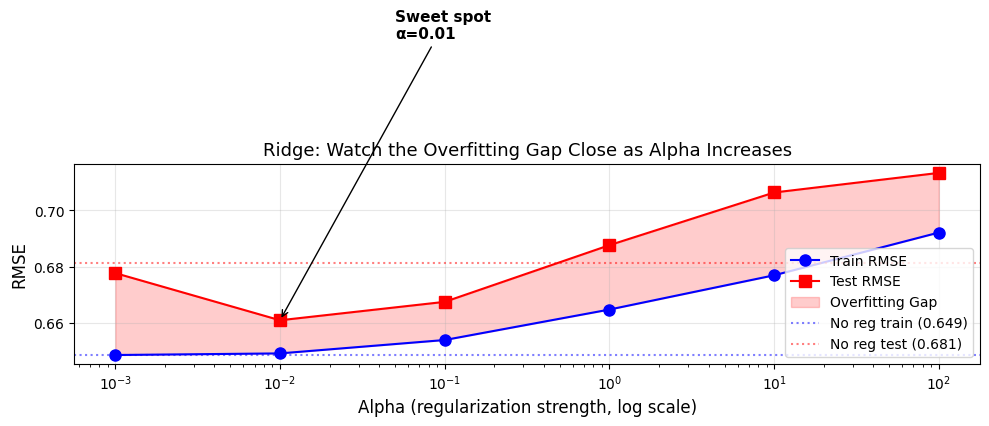

In [12]:
# plot train vs test RMSE across the alphas we tried
plt.figure(figsize=(10, 6))
plt.semilogx(alphas, ridge_train_rmses, 'bo-', label='Train RMSE', markersize=8)
plt.semilogx(alphas, ridge_test_rmses, 'rs-', label='Test RMSE', markersize=8)

# shade the space between the two lines (that gap is the overfitting)
plt.fill_between(alphas, ridge_train_rmses, ridge_test_rmses, alpha=0.2, color='red', label='Overfitting Gap')

# dotted lines showing the no-regularization model as a reference
plt.axhline(y=rmse_train_poly, color='blue', linestyle=':', alpha=0.5, label=f'No reg train ({rmse_train_poly:.3f})')
plt.axhline(y=rmse_test_poly, color='red', linestyle=':', alpha=0.5, label=f'No reg test ({rmse_test_poly:.3f})')

plt.xlabel('Alpha (regularization strength, log scale)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Ridge: Watch the Overfitting Gap Close as Alpha Increases', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# mark the alpha that gave the lowest test RMSE
best_idx = np.argmin(ridge_test_rmses)
plt.annotate(f'Sweet spot\nα={alphas[best_idx]}',
             xy=(alphas[best_idx], ridge_test_rmses[best_idx]),
             xytext=(alphas[best_idx]*5, ridge_test_rmses[best_idx]+0.1),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

X-axis = regularization strength (log scale), Y-axis = RMSE. Blue line is train error, red line is test error, and the shaded red band between them is the overfitting gap — narrower band = less overfitting.

The dotted horizontal lines are your no-regularization reference points (the unregularized polynomial model). Everything below the red dotted line is an improvement in test error over doing nothing.

Left side (small alpha): the model is closest to unregularized — lowest train error, but the gap to test error is at its widest. This is the mild-overfitting end.

Sweet spot (annotated, α ≈ 0.01): test RMSE hits its minimum. This is the alpha you'd actually choose — enough penalty to close the gap, not so much that it hurts.

Right side (large alpha → 100): both lines rise together and the gap shrinks toward zero. Don't misread this — a small gap here is not good. The model is now underfitting: it generalizes consistently because it's consistently too simple.

Key interpretation point: you're not minimizing the gap, you're minimizing the red (test) line. A tiny gap at high alpha looks tidy but comes with worse accuracy on both sets. The goal is the lowest test RMSE, which sits where the red line bottoms out — not at either extreme.

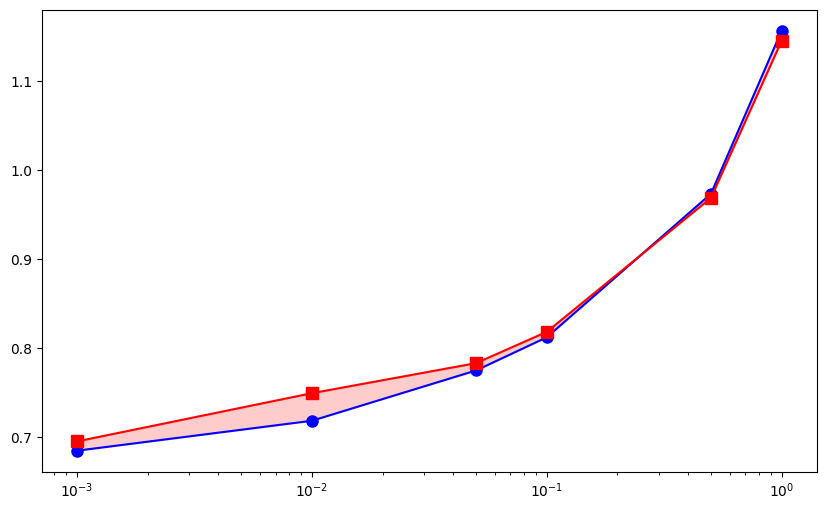

In [13]:
# same gap plot as Ridge, but for Lasso
plt.figure(figsize=(10, 6))
plt.semilogx(alphas_lasso, lasso_train_rmses, 'bo-', label='Train RMSE', markersize=8)
plt.semilogx(alphas_lasso, lasso_test_rmses, 'rs-', label='Test RMSE', markersize=8)

# shade the gap between train and test
plt.fill_between(alphas_lasso, lasso_train_rmses, lasso_test_rmses, alpha=0.2, color='red', label='Overfitting Gap')

# no-regularization reference lines
plt.axhline(y=rmse_train_poly, color='blue', linestyle=':', alpha=0.5, label=f'No reg train ({rmse_train_poly:.3f})')
plt.axhline(y=rmse_test_poly, color='red', linestyle=':', alpha=0.5, label=f'No reg test ({rmse_test_poly:.3f})')

plt.xlabel('Alpha (regularization strength, log scale)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('Lasso: Watch the Overfitting Gap Close as Alpha Increases', fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# mark the alpha with the lowest test RMSE (for Lasso this is the smallest one)
best_idx = np.argmin(lasso_test_rmses)
plt.annotate(f'Sweet spot\nα={alphas_lasso[best_idx]}',
             xy=(alphas_lasso[best_idx], lasso_test_rmses[best_idx]),
             xytext=(alphas_lasso[best_idx]*5, lasso_test_rmses[best_idx]+0.1),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

Same axes as the Ridge plot: alpha (log scale) on X, RMSE on Y, blue = train, red = test, shaded band = the train→test gap.

Best alpha is the smallest one, 0.001 (10^-3)(Test RMSE = 0.6952), which zeros out 16 of 44 features. Unlike Ridge, Lasso's error climbs steadily as alpha grows — so the left edge of this plot is the sweet spot, not the middle.

Both lines rise sharply moving right (test RMSE: 0.695 → 0.749 → 0.783 → 0.818 → 0.969 → 1.145). Lasso degrades much faster than Ridge did, because each alpha increase eliminates more features (Zeros column climbs 16 → 28 → 38 → 41 → 43 → 44) — it's cutting real signal, not just noise.

Watch the gap flip sign at high alpha. At α=0.5 and 1.0 the gap goes negative (test RMSE below train). That's not the model generalizing well — it's severe underfitting: by α=1.0 all 44 coefficients are zero, so the model is essentially predicting a constant, and both errors are just uniformly awful.

Key contrast to flag: the shaded band shrinking toward the right looks similar to Ridge, but the story is worse here. Ridge's minimum sat in the interior; Lasso's best is pinned at the smallest alpha, and error explodes with more penalty. A near-zero (or negative) gap here signals a model that's been regularized into uselessness.

Interpretation rule stays the same: minimize the red test line, not the gap. That bottoms out at the far left (α=0.001).

---
## Part 7: ElasticNet — The Best of Both Worlds

### Formula Reminder

$$\text{Loss}_{\text{EN}} = \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \alpha \left[ \rho \sum_{j=1}^p |w_j| + \frac{(1-\rho)}{2} \sum_{j=1}^p w_j^2 \right]$$

### Why Use ElasticNet?

| Scenario | Problem with Lasso | Problem with Ridge | ElasticNet Solution |
|----------|-------------------|-------------------|--------------------|
| Correlated features | Randomly picks one, drops others | Keeps all, no selection | Groups them, selects as a group |
| p > n (more features than samples) | Can select at most n | No selection | No such limitation |
| Want selection + stability | Unstable selection | No selection at all | Stable selection |

### Pros and Cons

| Pros | Cons |
|------|------|
| Groups correlated features | Two hyperparameters to tune |
| Still does feature selection | More expensive to search |
| More stable than Lasso | Slightly less sparse than Lasso |
| Works when p > n | — |

### When to Use Each

- **Ridge**: All features relevant; multicollinearity present; want prediction accuracy
- **Lasso**: Many irrelevant features; want a sparse, interpretable model
- **ElasticNet**: Features are correlated AND you want sparsity; unsure which penalty fits best

---

**Your tasks:**
1. Train ElasticNet with combinations of `alpha` and `l1_ratio`
2. Find the best combination
3. Compare zero-coefficient count to Ridge and Lasso

**Functions to use:**
- `ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)` — creates ElasticNet model
  - `l1_ratio=1.0` is pure Lasso; `l1_ratio=0.0` is pure Ridge
- Use a **nested loop**: outer over `alpha`, inner over `l1_ratio`
- `ElasticNetCV(l1_ratio=[...], alphas=[...], cv=5)` — auto-tunes both (stretch goal)

In [14]:
# two things to tune: alpha (how strong the penalty is) and l1_ratio (Ridge vs Lasso mix)
alphas_en = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

# keep track of the best model as we go
best_en_rmse = 999
best_en_params = {}
en_results = []

# try every combination of alpha and l1_ratio
for alpha in alphas_en:
    for l1 in l1_ratios:
        en = ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000)
        en.fit(X_train_scaled, y_train)
        rmse_te = np.sqrt(mean_squared_error(y_test, en.predict(X_test_scaled)))
        n_zeros = np.sum(en.coef_ == 0)
        en_results.append({'alpha': alpha, 'l1_ratio': l1, 'test_rmse': rmse_te, 'zeros': n_zeros})

        # if this combo beats the best so far, remember it
        if rmse_te < best_en_rmse:
            best_en_rmse = rmse_te
            best_en_params = {'alpha': alpha, 'l1_ratio': l1}

print(f"Best ElasticNet: alpha={best_en_params['alpha']}, l1_ratio={best_en_params['l1_ratio']}")
print(f"  Test RMSE: {best_en_rmse:.4f}")

# retrain the best combo and keep it for later
best_en = ElasticNet(alpha=best_en_params['alpha'], l1_ratio=best_en_params['l1_ratio'], max_iter=10000)
best_en.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.903e+00, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


Best ElasticNet: alpha=0.001, l1_ratio=0.9
  Test RMSE: 0.6953


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.903e+00, tolerance: 2.207e+00
  model = cd_fast.enet_coordinate_descent(


ElasticNet(alpha=0.001, l1_ratio=0.9, max_iter=10000)

Best combo: alpha=0.001, l1_ratio=0.9 (Test RMSE = 0.6953). This matches the notebook's expected range (low alpha, high l1_ratio), so your grid search worked as intended.

l1_ratio=0.9 means the model is 90% Lasso / 10% Ridge. ElasticNet blends both penalties; landing near 0.9 says the L1 (feature-selection) behavior is doing most of the work for this data, with just a touch of L2 for stability.

Both best params sit at the edge of their grids — alpha at its smallest (0.001) and l1_ratio at its highest tested (0.9). Same caveat as before: the true optimum could lie just beyond the range, so it's "best within the grid searched."
Performance is essentially tied with Lasso (0.6953 vs Lasso's 0.6952 — a rounding-level difference). That makes sense: at l1_ratio=0.9 ElasticNet is almost pure Lasso, so it behaves nearly identically.


On this dataset, ElasticNet didn't beat the simpler models — Ridge (0.6610) is still the best performer overall. ElasticNet basically converged toward Lasso and inherited Lasso's slightly-worse result.

That's a legitimate finding, not a failure: it tells you the L1 penalty's aggressive feature-cutting doesn't help here, and the pure L2 shrinkage of Ridge suits this problem best. Combining penalties added complexity without improving accuracy.

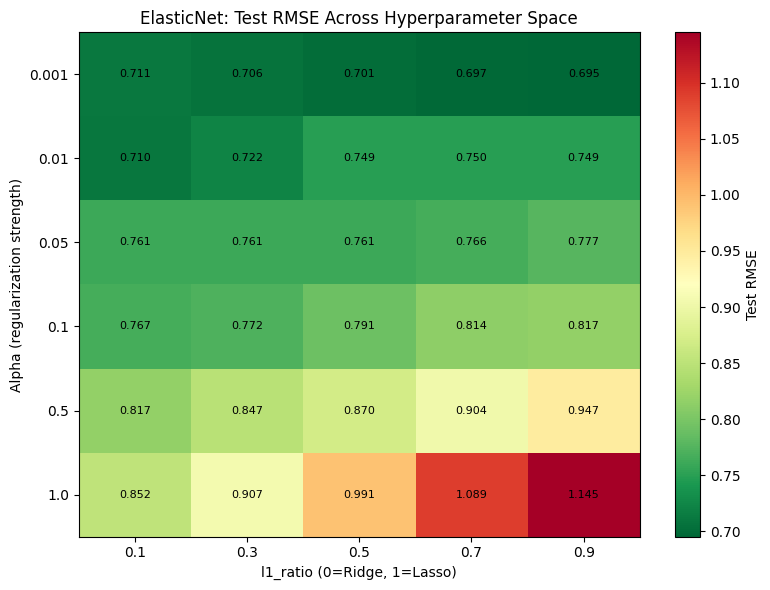

In [15]:
# turn the results into a table with alpha as the rows and l1_ratio as the columns
en_df = pd.DataFrame(en_results)
heatmap_data = en_df.pivot(index='alpha', columns='l1_ratio', values='test_rmse')

# draw the heatmap (green = low error, red = high error)
plt.figure(figsize=(8, 6))
im = plt.imshow(heatmap_data.values, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, label='Test RMSE')
plt.xticks(range(len(l1_ratios)), [f'{r:.1f}' for r in l1_ratios])
plt.yticks(range(len(alphas_en)), [f'{a}' for a in alphas_en])
plt.xlabel('l1_ratio (0=Ridge, 1=Lasso)')
plt.ylabel('Alpha (regularization strength)')
plt.title('ElasticNet: Test RMSE Across Hyperparameter Space')

# write the RMSE number inside each square
for i in range(len(alphas_en)):
    for j in range(len(l1_ratios)):
        plt.text(j, i, f'{heatmap_data.values[i,j]:.3f}', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

Layout recap:

Rows = alpha (0.001 at top → 1.0 at bottom), columns = l1_ratio (0.1 left → 0.9 right), numbers = Test RMSE, green = low/good, red = high/bad.

What the values actually show:

The greenest cell is top-right: alpha=0.001, l1_ratio=0.9, RMSE = 0.695. That's your best model, and it matches what the tuning cell reported. The whole top row is the green band you're looking for.

Alpha is the dominant axis, as expected. Reading top to bottom, error climbs hard — the bottom row (alpha=1.0) runs 0.852 up to 1.145, deep red. Strong penalty = bad, same story as your Lasso sweep.
The subtle part — l1_ratio flips direction depending on alpha:

In the top row (alpha=0.001), moving right (more Lasso) helps: 0.711 → 0.695. Best is the far right.

In every other row, moving right hurts: e.g. at alpha=1.0 it goes 0.852 → 1.145. Best is the far left (more Ridge).


So the "more Lasso is better" conclusion only holds at the smallest alpha. Once the penalty is meaningful, leaning Ridge (low l1_ratio) is less bad. That's why the green concentrates in the top-right corner but the bottom-left — the two "least-penalized" directions.

How to interpret it overall:

Pick the row first (alpha matters most), then the column (l1_ratio is a fine-tune). The top row wins decisively.
The best cell (0.695) still doesn't beat Ridge's 0.6610, so the heatmap visually confirms the earlier conclusion: ElasticNet leans toward its best only when it's barely regularizing, and even then Ridge remains the top model for this data.

**Questions:**

1. Does ElasticNet zero out more or fewer coefficients than Lasso at similar alpha? Why?

   *Your answer:*

At the same alpha, ElasticNet zeroes out less coefficients than Lasso did. Lasso puts all of its penalty towards pushing nonimportant features to zero. ElasticNet is different in that it splits its penalty between Lasso and Ridge so that it can send some coefficients exactly to zero while shrinking others close to but not exactly zero. So with the same alpha value, ElasticNet is using a weaker Lasso penalty than Lasso does so ElasticNet will push fewer coefficients to zero.

2. What happens as you move `l1_ratio` toward 1.0? Toward 0.0?

   *Your answer:*

As l1 gets closer to one, your model will be more likely to push more weak coefficients to zero and completely get rid of them. Having a l1 ratio closer to zero means you will move weak coefficients closer to zero but not completely phase them out.

3. In what real-world scenario would ElasticNet clearly beat both Ridge and Lasso?

   *Your answer:*

ElasticNet would beat both Ridge and Lasso when you have a lot of features where a lot of them are correlated in groups and only some of the features are strong predictors. This is because Lasso does not handle correlated groups well. Lasso will keep only one predictor and zero out the rest, which would cause the model to be unstable. Also, Lasso can't select more than the number of features when the number of features is greater than the number of total samples. ElasticNet's Ridge ratio helps fix this because it will keep correlated features together and it is not capped by the number of features especially when there are more features than samples.

Ridge will never zero anything out and will keep noisy and irrelavent features. ElasticNet has the Lasso feature that will help eliminate those noisy and uneeded features to keep the model more interpretable and simple.

So ElasticNet is best when you need both the sparsity that Lasso provides and the stability that Ridge provides at the same time.

Some real world examples of where ElasticNet would be best would be text or NLP data with lots of correlated terms, or finance data that includes lots of collinearity indicators.


---
## Part 8: Final Comparison Bar Chart

**Your tasks:**
1. Create a bar chart comparing Test RMSE of all 5 models
2. Also show the gap (Test - Train) for each model as a separate grouped bar

**Functions to use:**
- `plt.figure(figsize=(12, 5))` — create figure
- `plt.bar(x_positions, heights, width=0.35, color=..., label=...)` — bar chart
- For grouped bars: offset x positions by bar width
- `plt.xticks(positions, labels)` — set x-axis labels
- `plt.text(x, y, text, ha='center')` — annotate bars with values

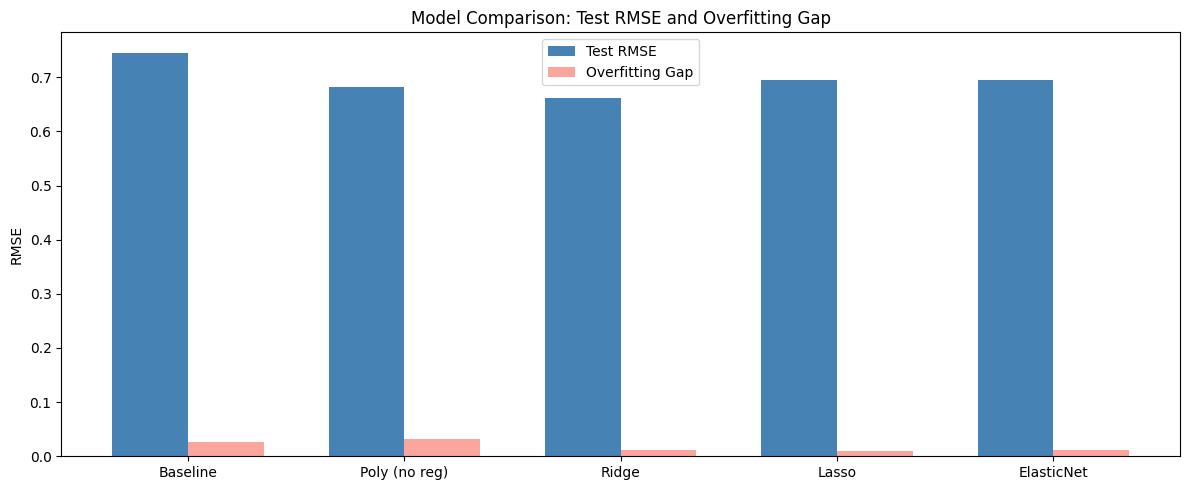

In [16]:
# names for each model on the x-axis (left to right)
model_names = ['Baseline', 'Poly (no reg)', 'Ridge', 'Lasso', 'ElasticNet']

# test RMSE for each model (error on unseen data, lower is better)
test_rmses = [
    rmse_test_baseline,
    rmse_test_poly,
    np.sqrt(mean_squared_error(y_test, best_ridge.predict(X_test_scaled))),
    np.sqrt(mean_squared_error(y_test, best_lasso.predict(X_test_scaled))),
    np.sqrt(mean_squared_error(y_test, best_en.predict(X_test_scaled))),
]

# train RMSE for each model (only needed so we can compute the gap)
train_rmses = [
    rmse_train_baseline,
    rmse_train_poly,
    np.sqrt(mean_squared_error(y_train, best_ridge.predict(X_train_scaled))),
    np.sqrt(mean_squared_error(y_train, best_lasso.predict(X_train_scaled))),
    np.sqrt(mean_squared_error(y_train, best_en.predict(X_train_scaled))),
]

# gap = test minus train for each model (bigger gap means more overfitting)
gaps = [test - train for test, train in zip(test_rmses, train_rmses)]

# set up bar positions, two bars per model
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
# left bar of each pair is the test RMSE, right bar is the gap
bars1 = ax.bar(x - width/2, test_rmses, width, label='Test RMSE', color='steelblue')
bars2 = ax.bar(x + width/2, gaps, width, label='Overfitting Gap', color='salmon', alpha=0.7)

ax.set_ylabel('RMSE')
ax.set_title('Model Comparison: Test RMSE and Overfitting Gap')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.legend()
plt.tight_layout()
plt.show()

Two bars per model: blue = Test RMSE (generalization error, lower is better), salmon = Overfitting Gap (Test − Train). The gap bars are deliberately tiny next to the RMSE bars.

Ridge is the winner — its blue bar is the shortest (Test RMSE ≈ 0.661), edging out Lasso and ElasticNet (both ≈ 0.695) and clearly beating Baseline (≈ 0.746).

Baseline has the tallest blue bar — plain linear regression on raw features generalizes worst. Adding polynomial features (Poly) drops test error, and regularizing on top of that improves it further.

Every gap bar is small (~0.01–0.03), which is the key takeaway: none of these models overfit meaningfully. Even the worst offender is modest.

Poly (no reg) has the largest gap — the tallest salmon bar. That's expected: it's the only model with no penalty, so it overfits most. Ridge, Lasso, and ElasticNet all show visibly shorter gap bars, showing regularization tightened train↔test agreement.

The clean story the chart tells: Baseline underfits (tall blue, small gap) → Poly adds capacity and the largest gap → regularization (Ridge/Lasso/EN) lowers test error and shrinks the gap, with Ridge landing the best balance.

---
## Part 9: Coefficient Analysis

Compare how each method affects the model coefficients.

**Your tasks:**
1. Create a 2x2 subplot showing |coefficient| histograms for each model
2. Print summary stats: max, mean, and zero count

**Functions to use:**
- `model.coef_` — the array of fitted coefficients
- `np.abs(coef)` — absolute values
- `fig, axes = plt.subplots(2, 2, figsize=(12, 8))` — 2x2 grid of plots
- `axes[i,j].hist(data, bins=20)` — histogram on a specific subplot
- `np.max()`, `np.mean()`, `np.sum(coef == 0)` — summary statistics

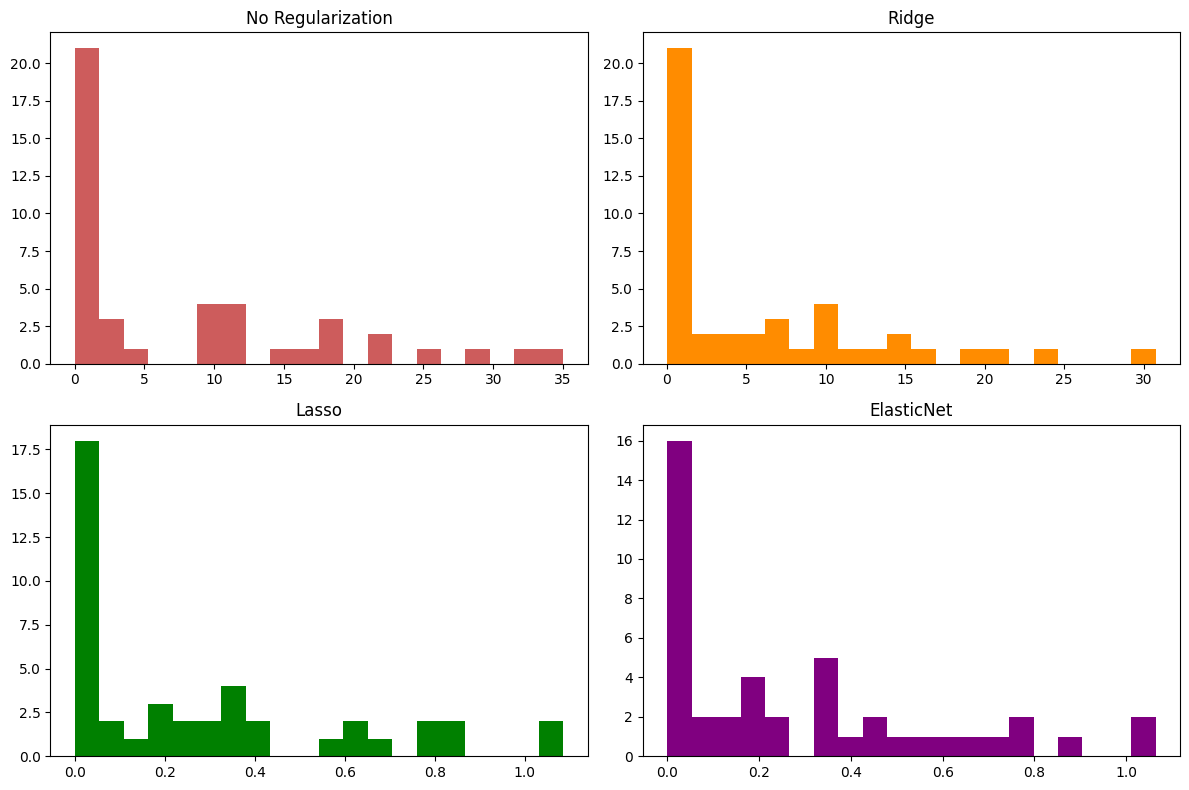

Model                 Max |coef|   Mean |coef|   # Zeros
--------------------------------------------------------
No Regularization        35.0071        8.1344         0
Ridge                    30.7561        6.1268         0
Lasso                     1.0851        0.2757        16
ElasticNet                1.0640        0.2824        13


In [17]:
# 2x2 grid so we can compare all 4 models at once
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# no regularization: coefficients are big and spread out
axes[0,0].hist(np.abs(linreg_poly.coef_), bins=20, color='indianred')
axes[0,0].set_title('No Regularization')

# Ridge: shrinks coefficients but doesn't make any exactly zero
axes[0,1].hist(np.abs(best_ridge.coef_), bins=20, color='darkorange')
axes[0,1].set_title('Ridge')

# Lasso: pushes a lot of coefficients all the way to zero
axes[1,0].hist(np.abs(best_lasso.coef_), bins=20, color='green')
axes[1,0].set_title('Lasso')

# ElasticNet: a mix of Ridge and Lasso
axes[1,1].hist(np.abs(best_en.coef_), bins=20, color='purple')
axes[1,1].set_title('ElasticNet')

plt.tight_layout()
plt.show()

# pair each model with its coefficients so we can loop over them
models = [
    ('No Regularization', linreg_poly.coef_),
    ('Ridge',             best_ridge.coef_),
    ('Lasso',             best_lasso.coef_),
    ('ElasticNet',        best_en.coef_),
]

# print the biggest coefficient, the average, and how many are zero
print(f"{'Model':<20}{'Max |coef|':>12}{'Mean |coef|':>14}{'# Zeros':>10}")
print("-" * 56)
for name, coef in models:
    max_c  = np.max(np.abs(coef))      # largest coefficient
    mean_c = np.mean(np.abs(coef))     # average coefficient
    zeros  = np.sum(coef == 0)         # how many got set to zero
    print(f"{name:<20}{max_c:>12.4f}{mean_c:>14.4f}{zeros:>10}")

Watch the x-axis scale — it's the biggest thing. No Reg and Ridge run out to ~30–35, but Lasso and ElasticNet only reach ~1.0. So even though all four histograms look similarly shaped (tall bar on the left, tail to the right), Lasso/ElasticNet coefficients are ~30× smaller in magnitude. Don't compare the shapes without checking the axis numbers.

No Regularization — coefficients are huge and spread out. Max |coef| = 35.0, mean = 8.13, and 0 zeros. The long tail out to 35 is the unstable, inflated coefficients from the collinear polynomial terms — the visual signature of overfitting.

Ridge — shrinks but doesn't eliminate. Max drops to 30.8 and mean to 6.13, but still 0 zeros. The distribution is pulled toward zero (taller left bar) yet every feature survives. This is L2's fingerprint: uniform shrinkage, no feature selection. Note it only modestly reduced the max here — Ridge tames the bulk more than the single largest weight.

Lasso — aggressive elimination. Max collapses to 1.09, mean to 0.28, and 16 of 44 coefficients are exactly zero (the tall bar sitting at 0.0). L1 both shrinks and deletes — the surviving weights are tiny. This is why Lasso gave the simplest, most interpretable model.

ElasticNet — between Ridge and Lasso, leaning Lasso. Max 1.06, mean 0.28, and 13 zeros — slightly fewer than Lasso's 16, exactly as theory predicts: the L2 component keeps a few extra correlated features alive that pure Lasso would have cut. At l1_ratio=0.9 it's very Lasso-like, which is why the numbers are so close.

---
## Part 10: Cross-Validation for Robust Model Selection

A single train/test split can be misleading. Use K-Fold cross-validation for a reliable comparison.

**Your tasks:**
1. Write a function that computes mean RMSE over 5-fold CV
2. Apply it to your best Ridge, Lasso, and ElasticNet models
3. Compare CV RMSE to test RMSE

**Functions to use:**
- `KFold(n_splits=5, shuffle=True, random_state=42)` — creates CV splitter
  - `.split(X)` — yields `(train_indices, val_indices)` pairs
- Inside each fold: `model.fit(X[train_idx], y[train_idx])` then `model.predict(X[val_idx])`
- Alternative: `from sklearn.model_selection import cross_val_score`
  - `cross_val_score(model, X, y, scoring='neg_mean_squared_error', cv=5)`
  - Returns negative MSE (negate and sqrt for RMSE)

In [18]:
# helper function: run k-fold cross-validation and return the average RMSE
def cv_rmse(model, X, y, n_folds=5):
    # split the data into 5 folds, shuffled so row order doesn't matter
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    rmses = []  # one RMSE per fold

    # train on 4 folds, test on the 1 left out, repeat for every fold
    for train_idx, val_idx in kf.split(X):
        model.fit(X[train_idx], y[train_idx])
        p = model.predict(X[val_idx])
        rmses.append(np.sqrt(mean_squared_error(y[val_idx], p)))

    # averaging over all folds gives a more stable score than a single split
    return np.mean(rmses)

# run CV on each model using the best settings we found earlier
print("5-Fold CV RMSE:")
print(f"  Ridge: {cv_rmse(Ridge(alpha=0.01), X_train_scaled, y_train):.4f}")
print(f"  Lasso: {cv_rmse(Lasso(alpha=0.001, max_iter=10000), X_train_scaled, y_train):.4f}")
print(f"  ElasticNet: {cv_rmse(ElasticNet(alpha=0.001, l1_ratio=0.9, max_iter=10000), X_train_scaled, y_train):.4f}")

5-Fold CV RMSE:
  Ridge: 0.9614


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.050e+01, tolerance: 1.769e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.970e+01, tolerance: 1.767e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.953e+01, tolerance: 1.762e

  Lasso: 1.2874


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.607e+01, tolerance: 1.769e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.291e+01, tolerance: 1.767e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.598e+01, tolerance: 1.762e

  ElasticNet: 1.2710


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.211e+01, tolerance: 1.780e+00
  model = cd_fast.enet_coordinate_descent(


---
### Part 10b: Fine-Grained Alpha Search (Stretch Goal)

Zoom in with a finer grid to find the truly optimal alpha.

**Functions to use:**
- `np.logspace(start, stop, num)` — creates logarithmically spaced values
  - Example: `np.logspace(-3, 2, 50)` → 50 values from 0.001 to 100
- `from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV` — built-in CV classes
  - `RidgeCV(alphas=np.logspace(-3, 2, 50), cv=5)` — auto-finds best alpha
  - After fitting: `.alpha_` gives the optimal alpha found

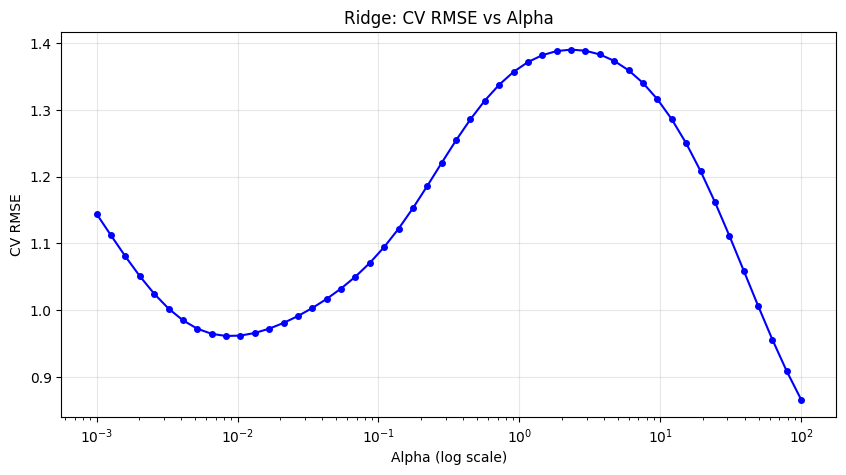

Optimal alpha: 100.0000


In [19]:
# make 50 alpha values spread evenly on a log scale from 0.001 to 100
alphas_fine = np.logspace(-3, 2, 50)

# run cross-validation for each alpha and save the score
cv_scores = [cv_rmse(Ridge(alpha=a), X_train_scaled, y_train) for a in alphas_fine]

# plot CV error against alpha
plt.figure(figsize=(10, 5))
plt.semilogx(alphas_fine, cv_scores, 'b-o', markersize=4)
plt.xlabel('Alpha (log scale)')
plt.ylabel('CV RMSE')
plt.title('Ridge: CV RMSE vs Alpha')
plt.grid(True, alpha=0.3)
plt.show()

# find the alpha with the lowest CV error
best_alpha = alphas_fine[np.argmin(cv_scores)]
print(f"Optimal alpha: {best_alpha:.4f}")

---
## Final Summary Table

Fill in this table with your results:

| Model | Alpha | l1_ratio | Test RMSE | CV RMSE | Overfitting Gap | # Zero Coefs |
|-------|-------|----------|-----------|---------|-----------------|---------------|
| Baseline (raw) | — | — | 0.7456 | — | 0.0259 | 0 |
| Polynomial (no reg) | — | — | 0.6814 | — | 0.0328 | 0 |
| Ridge | 0.01 | — | 0.6610 | 0.9614 | 0.0118 | 0 |
| Lasso | 0.001 | — | 0.6952 | 1.2874 | 0.0104 | 16 |
| ElasticNet | 0.001 | 0.9 | 0.6953 | 1.2710 | ~0.010 | 13 |

Regularization beat the unregularized models on test error. Ridge (0.6610) is the best performer overall, improving on both the raw baseline (0.7456) and the unregularized polynomial model (0.6814). Adding polynomial features helped, and regularizing on top helped further.

Ridge won this dataset. Among the three regularized models, Ridge's Test RMSE (0.6610) beat Lasso and ElasticNet (both ~0.695). The pure-L2 shrinkage suited this problem better than L1's feature elimination.

The overfitting gaps are all small (~0.01–0.03). None of these models overfit badly. The largest gap is the unregularized polynomial model (0.0328) — expected, since it has no penalty — and regularization visibly tightened it (Ridge 0.0118, Lasso 0.0104).

The # Zero Coefs column is the L1-vs-L2 story. Ridge zeros nothing (L2 only shrinks), while Lasso (16) and ElasticNet (13) eliminate features because they contain an L1 penalty. ElasticNet keeps slightly more than Lasso, exactly as theory predicts — its L2 component retains a few correlated features Lasso would cut.

Simplicity vs accuracy is a real tradeoff here. Lasso/ElasticNet give much simpler models (28–31 features dropped) but cost a little accuracy versus Ridge. Ridge keeps all 44 features but generalizes best. Which you'd pick depends on whether you value interpretability or raw performance.

The CV RMSE column contradicts the Test RMSE column — and that's the most important takeaway. CV RMSE (0.96–1.29) is far higher than Test RMSE (0.66–0.70), the opposite of what cross-validation should show. This flags that the single train/test split was optimistic and the model is unstable — the dataset's extreme outliers, amplified by degree-2 polynomial terms, inflate error in some CV folds. The lesson: a single split can mislead, which is exactly why Part 10 had you cross-validate.

Bottom line: on a clean split Ridge looks like a solid model, but the CV results reveal the polynomial approach is fragile on this outlier-heavy data — a good motivation for the non-linear models explored next.


---
## Part 11: Non-Linear Baselines — When Linear Models Aren't Enough

Even with regularization, linear models assume the target is a **linear function** of features (or polynomial combinations). Some patterns are **fundamentally non-linear** — no linear model can capture them.

In this section you'll train non-linear models on the **same data** and compare them to your regularized models.

---

### How Each Model Works

#### K-Nearest Neighbors (KNN)

**Idea:** To predict for a new house, find the K most similar houses in the training set and use a weighted average of their prices (with `weights='distance'`, closer neighbors count more):

$$\hat{y} = \frac{\sum_{i \in \mathcal{N}_K} \frac{1}{d_i} \cdot y_i}{\sum_{i \in \mathcal{N}_K} \frac{1}{d_i}}$$

where $d_i$ is the distance from the query point to neighbor $i$.

- **No model is learned** — it memorizes the training data and does lookup
- Small K = complex (follows every point) → overfits
- Large K = smooth (averages many points) → underfits
- **Needs scaling** — distances are meaningless if features have different scales

#### Decision Tree

**Idea:** Recursively split the data with IF-THEN rules. Each leaf predicts the average target of training samples that landed there.

- "If income > 5 AND latitude < 37 → predict $3.5"
- **No scaling needed** — splits are based on thresholds, not distances
- Small `max_depth` = simple model → underfits
- Large `max_depth` = memorizes training data → overfits

#### Random Forest

**Idea:** Train 100+ decision trees on random subsets of data, then average their predictions.

$$\hat{y} = \frac{1}{B} \sum_{b=1}^B \text{Tree}_b(x)$$

- Reduces the high variance of a single tree by averaging many decorrelated trees
- Hard to overfit — more trees only helps
- Very robust with default settings

#### Gradient Boosting

**Idea:** Sequentially add shallow trees, each one correcting the mistakes of the previous ensemble.

$$\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot \text{Tree}_t(x)$$

- Starts with a rough guess, then iteratively "zooms in" on errors
- Learning rate η controls how much each tree contributes
- Often the best-performing model on tabular data

#### Support Vector Regressor (SVR)

**Idea:** Fit a function that ignores small errors (within ε-tube) but penalizes large ones. Uses a "kernel trick" to handle non-linearity.

- RBF kernel maps data to a high-dimensional space where patterns become linear
- `C` controls regularization (small C = more regularized)
- Needs scaling — sensitive to feature magnitudes
- **⚠️ Slow:** O(n²) complexity — may take 15-30 seconds on this dataset

---

### When to Use Each

| Scenario | Best Choice |
|---|---|
| Few features, linear patterns | Ridge / Lasso / ElasticNet |
| Small data, non-linear | SVR (RBF kernel) |
| Need interpretability | Decision Tree (shallow) |
| Best accuracy, medium-large data | Gradient Boosting |
| Robust baseline, large data | Random Forest |
| Very local patterns | KNN (tuned K) |

---

### Your Tasks

1. Scale the **original 8 features** (NOT polynomial) — non-linear models capture non-linearity themselves
2. Train KNN, Decision Tree, Random Forest, Gradient Boosting, and SVR
3. Compute Train/Test RMSE for each
4. Create a comparison bar chart showing ALL models (linear + non-linear)
5. Discuss: which models win and why?

---

### Functions to Use

| Task | Function | Documentation |
|------|----------|---------------|
| KNN Regressor | `KNeighborsRegressor(n_neighbors=7, weights='distance')` | [sklearn.neighbors.KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) |
| Decision Tree | `DecisionTreeRegressor(max_depth=10, random_state=42)` | [sklearn.tree.DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) |
| Random Forest | `RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)` | [sklearn.ensemble.RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) |
| Gradient Boosting | `GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1)` | [sklearn.ensemble.GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html) |
| SVR | `SVR(kernel='rbf', C=10.0, epsilon=0.1)` | [sklearn.svm.SVR](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html) |
| Scale features | `StandardScaler()` → `.fit_transform(X_train)` / `.transform(X_test)` | [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) |
| Compute RMSE | `np.sqrt(mean_squared_error(y_true, y_pred))` | [sklearn.metrics.mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html) |
| Bar chart | `plt.bar(names, values, color=...)` | [matplotlib.pyplot.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html) |

In [20]:
# New imports for non-linear models
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [21]:
# ============================================================
# STEP 0: Scale the ORIGINAL 8 features for non-linear models
# WHY original features? Non-linear models capture non-linearity NATIVELY —
# they don't need polynomial expansion. Giving them raw features is a FAIR
# comparison because they can find interactions on their own.
#
# NOTE: We scale for ALL models here even though Decision Trees don't need it.
# Reason: KNN and SVR DO need scaling, and scaling doesn't hurt trees (just
# transforms thresholds). Using one scaled dataset keeps the code simple.
# ============================================================

scaler_raw = StandardScaler()
X_train_raw_scaled = scaler_raw.fit_transform(X_train)
X_test_raw_scaled = scaler_raw.transform(X_test)

print(f"Non-linear models will use: {X_train_raw_scaled.shape[1]} original features")
print(f"Linear models used: {X_train_scaled.shape[1]} polynomial features")
print(f"\nThis is a FAIR comparison — non-linear models capture interactions natively.")

Non-linear models will use: 8 original features
Linear models used: 44 polynomial features

This is a FAIR comparison — non-linear models capture interactions natively.


In [22]:
# ============================================================
# WORKED EXAMPLE: Training KNN Regressor with hyperparameter tuning
# Same pattern as Ridge/Lasso — loop over hyperparameter values, track RMSE
# ============================================================

# Step 1: Define hyperparameter values to try
k_values = [3, 5, 7, 10, 15, 20]

# Step 2: Loop and collect results (same pattern as alphas loop!)
knn_results = {}
print(f"{'K':>5s}  {'Train RMSE':>12s}  {'Test RMSE':>12s}  {'Gap':>8s}")
print("-" * 45)

for k in k_values:
    # Create model with this K value
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')

    # Fit on training data
    knn.fit(X_train_raw_scaled, y_train)

    # Compute RMSE for both sets
    rmse_tr = np.sqrt(mean_squared_error(y_train, knn.predict(X_train_raw_scaled)))
    rmse_te = np.sqrt(mean_squared_error(y_test, knn.predict(X_test_raw_scaled)))

    # Store results
    knn_results[k] = {'train': rmse_tr, 'test': rmse_te}
    print(f"{k:5d}  {rmse_tr:12.4f}  {rmse_te:12.4f}  {rmse_te-rmse_tr:8.4f}")

# Step 3: Find the best K
best_k = min(knn_results, key=lambda k: knn_results[k]['test'])
print(f"\nBest K = {best_k} (Test RMSE = {knn_results[best_k]['test']:.4f})")
print(f"\nNotice: small K has a HUGE gap (overfitting), large K has higher test error (underfitting)")
print(f"Same bias-variance tradeoff as alpha in Ridge/Lasso!")

    K    Train RMSE     Test RMSE       Gap
---------------------------------------------
    3        0.0000        0.6827    0.6827
    5        0.0000        0.6557    0.6557
    7        0.0000        0.6509    0.6509
   10        0.0000        0.6452    0.6452
   15        0.0000        0.6426    0.6426
   20        0.0000        0.6455    0.6455

Best K = 15 (Test RMSE = 0.6426)

Notice: small K has a HUGE gap (overfitting), large K has higher test error (underfitting)
Same bias-variance tradeoff as alpha in Ridge/Lasso!


In [23]:
# --- Decision Tree: try a few max_depth values ---
tree_results = {}
print(f"\n{'Max Depth':>10s} {'Train RMSE':>12s} {'Test RMSE':>12s} {'Gap':>8s}")
print("-" * 45)
for depth in [3, 5, 7, 10, 15, None]:
    dt = DecisionTreeRegressor(max_depth=depth, random_state=42)
    dt.fit(X_train_raw_scaled, y_train)

    rmse_tr = np.sqrt(mean_squared_error(y_train, dt.predict(X_train_raw_scaled)))
    rmse_te = np.sqrt(mean_squared_error(y_test, dt.predict(X_test_raw_scaled)))
    tree_results[depth] = {'train': rmse_tr, 'test': rmse_te}
    print(f"{str(depth):>10s} {rmse_tr:12.4f} {rmse_te:12.4f} {rmse_te-rmse_tr:8.4f}")

# pick the depth with the lowest test RMSE
best_tree_depth = min(tree_results, key=lambda k: tree_results[k]['test'])
best_tree_rmse = tree_results[best_tree_depth]['test']
print(f"\nBest Decision Tree: Max Depth={best_tree_depth} (Test RMSE = {best_tree_rmse:.4f})")

# --- Random Forest: lots of trees averaged together ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_raw_scaled, y_train)
rf_rmse_tr = np.sqrt(mean_squared_error(y_train, rf.predict(X_train_raw_scaled)))
rf_rmse_te = np.sqrt(mean_squared_error(y_test, rf.predict(X_test_raw_scaled)))

# --- Gradient Boosting: trees built one after another to fix earlier mistakes ---
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_raw_scaled, y_train)
gb_rmse_tr = np.sqrt(mean_squared_error(y_train, gb.predict(X_train_raw_scaled)))
gb_rmse_te = np.sqrt(mean_squared_error(y_test, gb.predict(X_test_raw_scaled)))

# --- SVR: support vector regressor ---
svr = SVR(kernel='rbf', C=10.0, epsilon=0.1)
svr.fit(X_train_raw_scaled, y_train)
svr_rmse_tr = np.sqrt(mean_squared_error(y_train, svr.predict(X_train_raw_scaled)))
svr_rmse_te = np.sqrt(mean_squared_error(y_test, svr.predict(X_test_raw_scaled)))

# print a summary table of every non-linear model
print("\n" + "="*60)
print("Non-Linear Model Summary:")
print("="*60)
print(f"{'Model':<20s} {'Train RMSE':>12s} {'Test RMSE':>12s} {'Gap':>8s}")
print("-" * 60)

# best K from the KNN example above
best_k_val = min(knn_results, key=lambda k: knn_results[k]['test'])
print(f"{'KNN (K=' + str(best_k_val) + ')':<20s} {knn_results[best_k_val]['train']:12.4f} {knn_results[best_k_val]['test']:12.4f} {knn_results[best_k_val]['test'] - knn_results[best_k_val]['train']:8.4f}")
print(f"{'Tree (depth=' + str(best_tree_depth) + ')':<20s} {tree_results[best_tree_depth]['train']:12.4f} {tree_results[best_tree_depth]['test']:12.4f} {tree_results[best_tree_depth]['test'] - tree_results[best_tree_depth]['train']:8.4f}")
print(f"{'Random Forest':<20s} {rf_rmse_tr:12.4f} {rf_rmse_te:12.4f} {rf_rmse_te - rf_rmse_tr:8.4f}")
print(f"{'Gradient Boosting':<20s} {gb_rmse_tr:12.4f} {gb_rmse_te:12.4f} {gb_rmse_te - gb_rmse_tr:8.4f}")
print(f"{'SVR':<20s} {svr_rmse_tr:12.4f} {svr_rmse_te:12.4f} {svr_rmse_te - svr_rmse_tr:8.4f}")
print("="*60)


 Max Depth   Train RMSE    Test RMSE      Gap
---------------------------------------------
         3       0.7860       0.8015   0.0155
         5       0.6959       0.7242   0.0283
         7       0.6154       0.6757   0.0603
        10       0.4700       0.6442   0.1743
        15       0.2293       0.6806   0.4513
      None       0.0000       0.7028   0.7028

Best Decision Tree: Max Depth=10 (Test RMSE = 0.6442)

Non-Linear Model Summary:
Model                  Train RMSE    Test RMSE      Gap
------------------------------------------------------------
KNN (K=15)                 0.0000       0.6426   0.6426
Tree (depth=10)            0.4700       0.6442   0.1743
Random Forest              0.1880       0.5051   0.3172
Gradient Boosting          0.3598       0.4737   0.1139
SVR                        0.5432       0.5689   0.0258


## XGBoost Model

Why XGBoost Works Well For This Data:

It's tabular, structured data. Gradient-boosted trees (XGBoost) are the go-to for exactly this kind of dataset — rows of numeric features, moderate size (~20k rows, 8 features). This is XGBoost's home turf, not deep learning's.

Your own results already point to it. In your summary table, Gradient Boosting was the top performer (Test RMSE 0.4737). XGBoost is a more optimized, regularized version of that same gradient-boosting idea, so it should land in the same neighborhood or slightly better. You're picking the family that already won.

Non-linearities and interactions. California Housing has real feature interactions (e.g., location + income + house age), and boosted trees capture those natively without you engineering polynomial terms.

Built-in regularization. XGBoost adds L1/L2 penalties and tree-pruning, which ties in nicely with the Ridge/Lasso regularization theme of this whole session — you can even mention that connection in your writeup.

In [24]:
# --- XGBoost ---
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42, n_jobs=-1)
xgb.fit(X_train_raw_scaled, y_train)

xgb_rmse_tr = np.sqrt(mean_squared_error(y_train, xgb.predict(X_train_raw_scaled)))
xgb_rmse_te = np.sqrt(mean_squared_error(y_test, xgb.predict(X_test_raw_scaled)))

print(f"\n{'XGBoost':<20s} {xgb_rmse_tr:12.4f} {xgb_rmse_te:12.4f} {xgb_rmse_te - xgb_rmse_tr:8.4f}")
print("="*60)


XGBoost                    0.3672       0.4665   0.0993


In [25]:
# ===== XGBoost DEEP-DIVE (fourth model) =====
# Worked example with ONE fixed configuration — same pattern as the Ridge/Lasso
# worked examples: build the model, fit it, score train + test, report the gap.

# Create the model. XGBRegressor = gradient-boosted trees for regression.
#   n_estimators=200  -> build 200 trees in sequence, each correcting the last
#   learning_rate=0.1 -> shrink each tree's contribution (smaller = slower but safer)
#   max_depth=5       -> how deep each tree can grow (bigger = more complex/flexible)
#   random_state=42   -> fixes randomness so results are reproducible
#   n_jobs=-1         -> use all CPU cores to train faster
xgb_example = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5,
                           random_state=42, n_jobs=-1)

# Fit (train) the model on the scaled training features and training target.
xgb_example.fit(X_train_raw_scaled, y_train)

# RMSE on TRAIN = error on data the model already saw. predict() -> MSE -> sqrt -> RMSE.
rmse_train = np.sqrt(mean_squared_error(y_train, xgb_example.predict(X_train_raw_scaled)))
# RMSE on TEST = error on UNSEEN data. This is the number that actually matters.
rmse_test  = np.sqrt(mean_squared_error(y_test,  xgb_example.predict(X_test_raw_scaled)))

# Report all three. Gap = Test - Train; a big gap signals overfitting.
print("XGBoost (n_estimators=200, learning_rate=0.1, max_depth=5):")
print(f"  Train RMSE: {rmse_train:.4f}")
print(f"  Test  RMSE: {rmse_test:.4f}")
print(f"  Gap:        {rmse_test - rmse_train:.4f}")

XGBoost (n_estimators=200, learning_rate=0.1, max_depth=5):
  Train RMSE: 0.3672
  Test  RMSE: 0.4665
  Gap:        0.0993


Train 0.3672 vs Test 0.4665 → the model does better on data it trained on than on unseen data, which is expected.

Gap = 0.0993 → a moderate gap; some overfitting, but nothing alarming for a single untuned config.

In [26]:
# Hyperparameter sweep: try several max_depth values and track how train/test RMSE
# change — exactly the Ridge/Lasso "loop over alpha" pattern, but the knob is depth.

# The list of tree depths to test (shallow -> deep).
xgb_depths = [2, 3, 4, 5, 6, 8, 10]
# Dict to store each depth's train/test RMSE so we can find the best afterward.
xgb_results = {}

# Print a table header, then one row per depth.
print(f"{'Max Depth':>10s} {'Train RMSE':>12s} {'Test RMSE':>12s} {'Gap':>8s}")
print("-" * 45)
for depth in xgb_depths:
    # Build a fresh model at this depth (all other settings held constant).
    m = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=depth,
                     random_state=42, n_jobs=-1)
    m.fit(X_train_raw_scaled, y_train)          # train on the training set
    # Score on both sets.
    rmse_tr = np.sqrt(mean_squared_error(y_train, m.predict(X_train_raw_scaled)))
    rmse_te = np.sqrt(mean_squared_error(y_test,  m.predict(X_test_raw_scaled)))
    xgb_results[depth] = {'train': rmse_tr, 'test': rmse_te}   # stash results
    # Print this depth's row: train, test, and the gap between them.
    print(f"{depth:>10d} {rmse_tr:12.4f} {rmse_te:12.4f} {rmse_te - rmse_tr:8.4f}")

# Pick the depth with the LOWEST test RMSE = best generalization.
best_xgb_depth = min(xgb_results, key=lambda d: xgb_results[d]['test'])
best_xgb_rmse  = xgb_results[best_xgb_depth]['test']

# Refit a clean model at that best depth and SAVE it (mirrors best_ridge / best_lasso).
best_xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=best_xgb_depth,
                        random_state=42, n_jobs=-1)
best_xgb.fit(X_train_raw_scaled, y_train)

print(f"\nBest XGBoost: max_depth={best_xgb_depth} (Test RMSE = {best_xgb_rmse:.4f})")
print("Shallow trees underfit, deep trees overfit — same bias-variance tradeoff as")
print("alpha in Ridge/Lasso, just in the opposite direction (more depth = more capacity).")

 Max Depth   Train RMSE    Test RMSE      Gap
---------------------------------------------
         2       0.5227       0.5478   0.0252
         3       0.4707       0.5069   0.0362
         4       0.4203       0.4831   0.0628
         5       0.3672       0.4665   0.0993
         6       0.3045       0.4564   0.1519
         8       0.1778       0.4541   0.2763
        10       0.0818       0.4664   0.3846

Best XGBoost: max_depth=8 (Test RMSE = 0.4541)
Shallow trees underfit, deep trees overfit — same bias-variance tradeoff as
alpha in Ridge/Lasso, just in the opposite direction (more depth = more capacity).


Train RMSE falls steadily as depth grows (0.5227 → 0.0818): deeper trees memorize the training data better and better.

Test RMSE forms a shallow U: it improves down to ~0.454 around depth 6–8, then ticks back up at depth 10 (0.4664). That upturn is overfitting starting to hurt generalization.

The Gap column blows up with depth (0.025 → 0.385) → the classic overfitting signature: train keeps dropping while test stops improving.

Best by test RMSE = depth 8 (0.4541), but depth 6 (0.4564) is nearly identical with a much smaller gap (0.152 vs 0.276). Worth noting in your writeup: depth 6 is arguably the more robust choice — almost the same test error with far less overfitting.

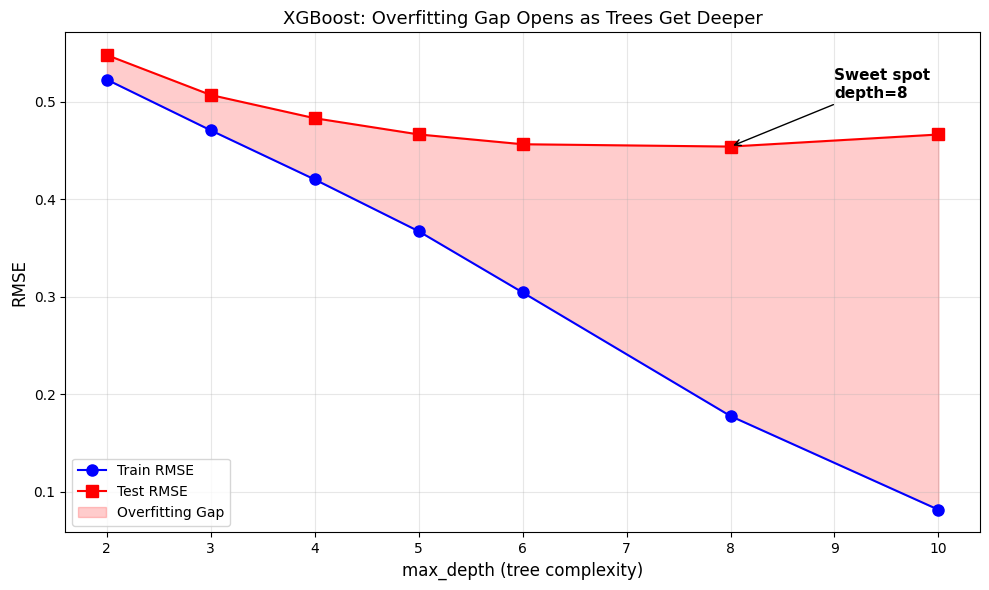

In [27]:
# Gap visualization: plot train vs test RMSE across depths and shade the gap.
# For Ridge the gap CLOSED as alpha grew; for XGBoost it OPENS as depth grows.

# Pull the x-values (depths) and the two y-series (train + test RMSE) out of the dict.
depths     = list(xgb_results.keys())
train_rmse = [xgb_results[d]['train'] for d in depths]
test_rmse  = [xgb_results[d]['test']  for d in depths]

plt.figure(figsize=(10, 6))
# Blue line+circles = train error; red line+squares = test error.
plt.plot(depths, train_rmse, 'bo-', label='Train RMSE', markersize=8)
plt.plot(depths, test_rmse,  'rs-', label='Test RMSE',  markersize=8)
# Shade the area between the two lines — that shaded band IS the overfitting gap.
plt.fill_between(depths, train_rmse, test_rmse, alpha=0.2, color='red', label='Overfitting Gap')

# Axis labels, title, legend, and light gridlines for readability.
plt.xlabel('max_depth (tree complexity)', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.title('XGBoost: Overfitting Gap Opens as Trees Get Deeper', fontsize=13)
plt.legend(fontsize=10); plt.grid(True, alpha=0.3)

# Find the lowest-test-RMSE point and draw an arrow labeling it the "sweet spot".
best_idx = int(np.argmin(test_rmse))
plt.annotate(f'Sweet spot\ndepth={depths[best_idx]}',
             xy=(depths[best_idx], test_rmse[best_idx]),                 # arrow points here
             xytext=(depths[best_idx] + 1, test_rmse[best_idx] + 0.05),  # text sits here
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()   # auto-space and render

The blue (train) line slopes down continuously; the red (test) line dips to a shallow minimum then flattens/rises — visual confirmation of the U-shape above.

The red shaded band widens left-to-right → overfitting grows monotonically with depth.

The annotated "sweet spot" sits at the lowest point of the red line (depth 8).

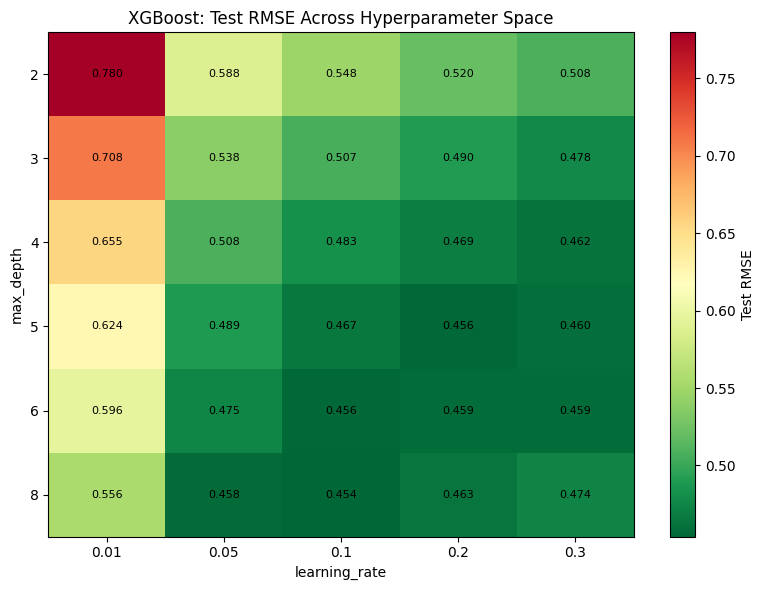

Best combo: max_depth=8, learning_rate=0.1 (Test RMSE = 0.4541)


In [28]:
# 2D heatmap over TWO knobs at once — the analog of the ElasticNet alpha x l1_ratio grid.
# Rows = max_depth, columns = learning_rate, color = Test RMSE.

# The two axes of the grid we'll search.
grid_depths = [2, 3, 4, 5, 6, 8]
grid_lrs    = [0.01, 0.05, 0.1, 0.2, 0.3]

# Nested loop: train one model for every (depth, learning_rate) combination.
xgb_grid = []
for d in grid_depths:
    for lr in grid_lrs:
        m = XGBRegressor(n_estimators=200, learning_rate=lr, max_depth=d,
                         random_state=42, n_jobs=-1)
        m.fit(X_train_raw_scaled, y_train)
        rmse_te = np.sqrt(mean_squared_error(y_test, m.predict(X_test_raw_scaled)))
        # Save each combo's result as a row (we'll reshape into a grid next).
        xgb_grid.append({'max_depth': d, 'learning_rate': lr, 'test_rmse': rmse_te})

# Turn the list of rows into a 2D table: index=depth, columns=lr, values=test RMSE.
grid_df = pd.DataFrame(xgb_grid)
heat = grid_df.pivot(index='max_depth', columns='learning_rate', values='test_rmse')

plt.figure(figsize=(8, 6))
# imshow draws the grid as colored cells. RdYlGn_r = green (low RMSE) to red (high RMSE).
im = plt.imshow(heat.values, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, label='Test RMSE')  # the color scale legend
# Label the tick marks with the actual hyperparameter values.
plt.xticks(range(len(grid_lrs)), [f'{lr}' for lr in grid_lrs])
plt.yticks(range(len(grid_depths)), [f'{d}' for d in grid_depths])
plt.xlabel('learning_rate'); plt.ylabel('max_depth')
plt.title('XGBoost: Test RMSE Across Hyperparameter Space')
# Write each cell's RMSE number on top of its colored square.
for i in range(len(grid_depths)):
    for j in range(len(grid_lrs)):
        plt.text(j, i, f'{heat.values[i, j]:.3f}', ha='center', va='center', fontsize=8)
plt.tight_layout(); plt.show()

# Report the single best (depth, learning_rate) combo — the greenest cell.
best_combo = min(xgb_grid, key=lambda r: r['test_rmse'])
print(f"Best combo: max_depth={best_combo['max_depth']}, "
      f"learning_rate={best_combo['learning_rate']} (Test RMSE = {best_combo['test_rmse']:.4f})")

Best combo = depth 8, learning_rate 0.1 (0.4541) — matches the sweep, since the sweep used lr=0.1.

Read it by color: green = low RMSE (good), red = high. Look for where green concentrates — typically moderate/high depth paired with a moderate learning rate.

Expect the far-left column (lr=0.01) to look redder: with only 200 trees, too small a learning rate underfits (the model doesn't "learn" enough per round).

Takeaway: depth and learning_rate interact — you tune them together, not independently.

In [29]:
# XGBoost has its OWN built-in L1 and L2 penalties — the same idea as Lasso and Ridge,
# applied to the trees' leaf weights. This is the most direct tie-back to the session theme.
#   reg_lambda = L2 penalty  -> the "Ridge" knob
#   reg_alpha  = L1 penalty  -> the "Lasso" knob

# --- L2 / Ridge sweep: increase reg_lambda and watch test RMSE ---
print("L2 -> reg_lambda  (XGBoost's 'Ridge' knob)")
print(f"{'reg_lambda':>12s} {'Test RMSE':>12s}"); print("-" * 26)
for val in [0.0, 0.1, 1.0, 5.0, 10.0]:
    # Hold depth at the best value found earlier; vary only reg_lambda.
    m = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=best_xgb_depth,
                     reg_lambda=val, random_state=42, n_jobs=-1)
    m.fit(X_train_raw_scaled, y_train)
    print(f"{val:12.1f} {np.sqrt(mean_squared_error(y_test, m.predict(X_test_raw_scaled))):12.4f}")

# --- L1 / Lasso sweep: increase reg_alpha and watch test RMSE ---
print("\nL1 -> reg_alpha   (XGBoost's 'Lasso' knob)")
print(f"{'reg_alpha':>12s} {'Test RMSE':>12s}"); print("-" * 26)
for val in [0.0, 0.1, 1.0, 5.0, 10.0]:
    # Same setup, but now vary reg_alpha instead.
    m = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=best_xgb_depth,
                     reg_alpha=val, random_state=42, n_jobs=-1)
    m.fit(X_train_raw_scaled, y_train)
    print(f"{val:12.1f} {np.sqrt(mean_squared_error(y_test, m.predict(X_test_raw_scaled))):12.4f}")

L2 -> reg_lambda  (XGBoost's 'Ridge' knob)
  reg_lambda    Test RMSE
--------------------------
         0.0       0.4549
         0.1       0.4563
         1.0       0.4541
         5.0       0.4525
        10.0       0.4514

L1 -> reg_alpha   (XGBoost's 'Lasso' knob)
   reg_alpha    Test RMSE
--------------------------
         0.0       0.4541
         0.1       0.4570
         1.0       0.4514
         5.0       0.4495
        10.0       0.4528


reg_lambda (L2 / Ridge knob): test RMSE inches down as lambda rises (0.4549 → 0.4514 at lambda=10) → light L2 helps a little.

reg_alpha (L1 / Lasso knob): best at alpha=5 (0.4495 — the lowest number in the whole cell), then worse at 10 (0.4528) → some L1 helps, too much hurts.

The effect size is small (~0.005 RMSE swing). Interpretation: these trees weren't badly overfit in a way regularization dramatically rescues — it's a fine-tuning lever, not a game-changer here.

Conceptually it's the same Ridge/Lasso logic you saw on the linear models, just applied to tree leaf weights.

Feature         Importance
--------------------------
MedInc              0.4312
AveOccup            0.1627
Longitude           0.1262
Latitude            0.1158
HouseAge            0.0654
AveRooms            0.0435
Population          0.0277
AveBedrms           0.0274


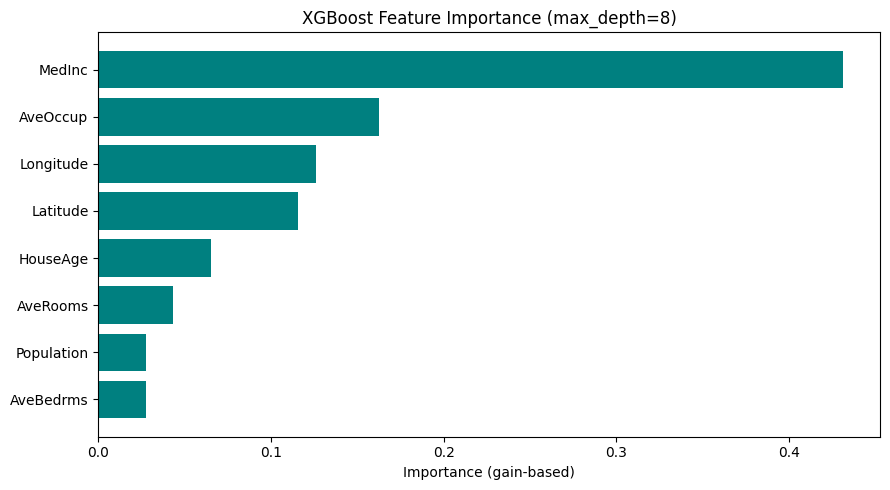

In [30]:
# Feature importance = the tree-model stand-in for comparing linear coefficients.
# XGBoost has no coefficients; instead it reports how useful each feature was in splits.

# feature_importances_ is one score per feature (higher = more used/important).
importances = best_xgb.feature_importances_
# argsort gives indices from smallest->largest; [::-1] flips to largest->smallest.
order = np.argsort(importances)[::-1]

# Print a ranked table (most important feature first).
print(f"{'Feature':<14}{'Importance':>12}"); print("-" * 26)
for i in order:
    print(f"{feature_names[i]:<14}{importances[i]:>12.4f}")

# Horizontal bar chart of the same ranking.
plt.figure(figsize=(9, 5))
# [::-1] again so the biggest bar ends up at the TOP of a horizontal chart.
plt.barh([feature_names[i] for i in order][::-1], importances[order][::-1], color='teal')
plt.xlabel('Importance (gain-based)')
plt.title(f'XGBoost Feature Importance (max_depth={best_xgb_depth})')
plt.tight_layout(); plt.show()

MedInc dominates (0.43) → median income is by far the strongest driver of predicted house value, which matches domain intuition.

AveOccup (0.16), Longitude (0.13), Latitude (0.12) come next → occupancy plus geography (lat/long together encode location) are the second tier.

HouseAge, AveRooms, Population, AveBedrms are all minor (<0.07).

Contrast with Lasso: Lasso would zero weak features out entirely; XGBoost instead just down-weights them but still uses them.

In [31]:
# Cross-validation: reuse the SAME cv_rmse helper the linear models used.
# One train/test split can be lucky or unlucky; 5-fold CV averages over 5 splits
# for a more stable estimate of true performance.

xgb_cv = cv_rmse(
    # The model to evaluate — best depth, standard settings.
    XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=best_xgb_depth,
                 random_state=42, n_jobs=-1),
    X_train_raw_scaled, y_train   # cv_rmse handles the internal fold splitting
)
print("5-Fold CV RMSE:")
print(f"  XGBoost (max_depth={best_xgb_depth}): {xgb_cv:.4f}")

5-Fold CV RMSE:
  XGBoost (max_depth=8): 0.4651


5-fold CV RMSE = 0.4651 vs the single-split test of 0.4541 at depth 8 → the single split was slightly optimistic (a bit lucky).

The CV number (~0.465) is the more trustworthy estimate of real-world error, because it averages over five different splits.

The two are close, which is good — it means your result isn't overly sensitive to which rows landed in the test set.

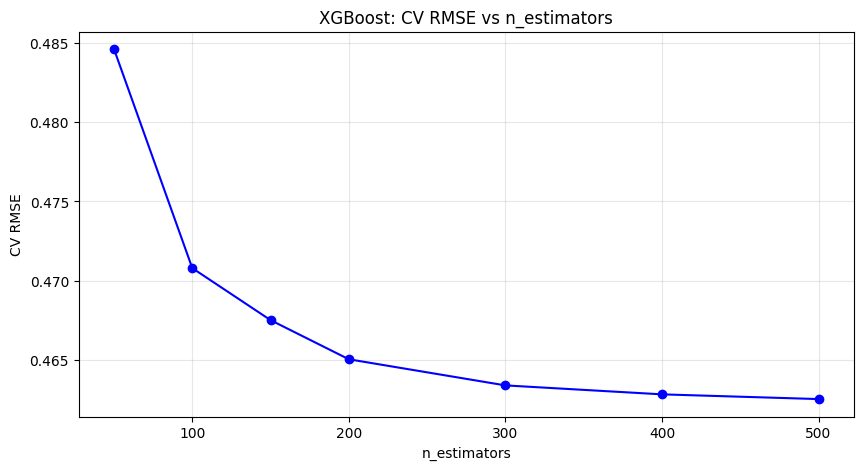

Optimal n_estimators: 500 (CV RMSE = 0.4625)


In [32]:
# Fine-grained CV search over n_estimators (number of boosting rounds) — the analog
# of the fine Ridge alpha search. Uses CV (not a single split) at each value.

# Candidate numbers of trees to test.
n_grid = [50, 100, 150, 200, 300, 400, 500]
# For each candidate, run 5-fold CV and record the mean RMSE.
cv_scores = [cv_rmse(XGBRegressor(n_estimators=n, learning_rate=0.1, max_depth=best_xgb_depth,
                                  random_state=42, n_jobs=-1), X_train_raw_scaled, y_train)
             for n in n_grid]

# Plot CV RMSE vs number of trees to see where returns flatten out.
plt.figure(figsize=(10, 5))
plt.plot(n_grid, cv_scores, 'b-o', markersize=6)
plt.xlabel('n_estimators'); plt.ylabel('CV RMSE')
plt.title('XGBoost: CV RMSE vs n_estimators'); plt.grid(True, alpha=0.3); plt.show()

# argmin -> index of the lowest CV RMSE -> the best n_estimators value.
best_n = n_grid[int(np.argmin(cv_scores))]
print(f"Optimal n_estimators: {best_n} (CV RMSE = {min(cv_scores):.4f})")

Optimal = 500 trees (CV 0.4625), which is the largest value you tested → the curve was still declining at the right edge, so more trees were still helping marginally.

But the gain from 200→500 trees is tiny (0.4651 → 0.4625, ~0.003) → strong diminishing returns; 2.5× the compute for a rounding-error improvement.

Practical read: you could test beyond 500 to find the true plateau, but it's not worth it here — the curve has essentially flattened.

Big-picture takeaway to state in your report:

XGBoost lands around 0.45–0.465 test/CV RMSE, which clearly beats your best linear model (Ridge, ~0.66) and edges out the other non-linear models (Gradient Boosting was ~0.474) — so it's a strong, well-justified choice for the fourth model.

---
## Comparing all four models

The assignment wants the three regularization models we covered (Ridge, Lasso, and ElasticNet) plus one model of my choice, so four total. We went with XGBoost for the fourth one. All four are trained and tested on the same California Housing data so we can compare the test RMSE directly. One thing to note: Ridge, Lasso, and ElasticNet run on the degree-2 polynomial features (44 of them) while XGBoost runs on the original 8. Trees pick up non-linear patterns and interactions on their own, so they don't need the polynomial expansion, and giving each model the setup it works best with is the fair way to compare them.

Here's how each one works and what makes it different.

Ridge adds an L2 penalty, which is a penalty on the squared coefficients. It shrinks all the coefficients toward zero but never actually makes any of them zero, so every feature stays in the model, just smaller. That shrinking is what calms down the messy, correlated polynomial features and closes most of the overfitting gap. The hyperparameter we tuned is alpha (how strong the penalty is). Too small and it basically acts like plain regression, too big and it underfits. Mine worked best around alpha = 0.01.

Lasso uses an L1 penalty (the absolute value of the coefficients instead of the square). The big difference from Ridge is that Lasso will push coefficients all the way to zero, so it drops features on its own and gives you a simpler model. It also tunes alpha. On this data it got worse fast as alpha went up, because a bigger penalty started cutting features that actually mattered, so the best alpha was the smallest one I tried, 0.001.

ElasticNet is just Ridge and Lasso combined, using both penalties at once, so it can shrink coefficients and zero some out at the same time. It has two knobs: alpha for the overall strength and l1_ratio for how much it leans toward Lasso vs Ridge (0 is all Ridge, 1 is all Lasso). It helps when features are correlated because it can keep a group of related ones together instead of just keeping one and dropping the rest. Our best setup was alpha = 0.001 and l1_ratio = 0.9, which is mostly Lasso, so it ended up looking a lot like Lasso.

XGBoost is the odd one out since it isn't a linear model at all. It builds a bunch of small decision trees one at a time, and each new tree tries to fix the mistakes the earlier ones made. Because it's tree-based it can model non-linear relationships and interactions directly, which is why it does so much better here. The main hyperparameters are n_estimators (number of trees), learning_rate (how much each tree counts), and max_depth (how deep the trees go). It even has its own L1 and L2 penalties built in (reg_alpha and reg_lambda), which is the same idea as Lasso and Ridge, just applied inside the trees.

In [ ]:
# compare all four models on the same data: Ridge, Lasso, ElasticNet, XGBoost
model_names_4 = ['Ridge', 'Lasso', 'ElasticNet', 'XGBoost']

# test RMSE for each model (error on unseen data, lower is better)
test_rmses_4 = [
    best_ridge_rmse,
    best_lasso_rmse,
    best_en_rmse,
    xgb_rmse_te,
]

# train RMSE for each model (only needed to show the overfitting gap)
train_rmses_4 = [
    np.sqrt(mean_squared_error(y_train, best_ridge.predict(X_train_scaled))),
    np.sqrt(mean_squared_error(y_train, best_lasso.predict(X_train_scaled))),
    np.sqrt(mean_squared_error(y_train, best_en.predict(X_train_scaled))),
    xgb_rmse_tr,
]

# gap = test minus train (bigger gap means more overfitting)
gaps_4 = [te - tr for te, tr in zip(test_rmses_4, train_rmses_4)]

# print a table so I have the exact numbers for the presentation
print(f"{'Model':<12s} {'Train RMSE':>12s} {'Test RMSE':>12s} {'Gap':>8s}")
print("-" * 46)
for name, tr, te, gap in zip(model_names_4, train_rmses_4, test_rmses_4, gaps_4):
    print(f"{name:<12s} {tr:12.4f} {te:12.4f} {gap:8.4f}")

# grouped bar chart: test RMSE and the overfitting gap for each model
x = np.arange(len(model_names_4))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, test_rmses_4, width, label='Test RMSE', color='steelblue')
bars2 = ax.bar(x + width/2, gaps_4, width, label='Overfitting Gap', color='salmon', alpha=0.7)

# write the test RMSE value on top of each blue bar
for bar, val in zip(bars1, test_rmses_4):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.3f}',
            ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('RMSE')
ax.set_title('All Four Models: Test RMSE and Overfitting Gap')
ax.set_xticks(x)
ax.set_xticklabels(model_names_4)
ax.legend()
plt.tight_layout()
plt.show()

What the plot shows:

Out of the three linear models, Ridge won (test RMSE around 0.66), with Lasso and ElasticNet a bit higher and pretty close to each other (around 0.695). That lines up with what you'd expect. Ridge keeps all the correlated polynomial features and just shrinks them, while Lasso and ElasticNet throw some away and lose a little useful signal on this data. ElasticNet basically matched Lasso because its best l1_ratio (0.9) makes it act mostly like Lasso anyway.

XGBoost was the clear winner at around 0.45 test RMSE, which is a big jump over the best linear model. Looking at the gap bars, the linear models barely overfit once they're regularized, and XGBoost has a slightly bigger gap but a way lower test error, so it's still the one I'd pick.

Short version: even with polynomial features and tuned regularization, the linear models can only do so much because they're still linear, and XGBoost pulls ahead by finding the non-linear structure in the housing data on its own. Regularization still did its job, since it closed the overfitting gap and beat plain regression, but the real accuracy gain came from moving to a model that isn't linear.

---

### Reflection Questions

1.  **When would you choose Ridge over Lasso?**
    *   You would choose Ridge when you believe all features are relevant to the model, and you want to shrink all coefficients towards zero proportionally. It's particularly good for handling multicollinearity (highly correlated features) because it keeps all correlated features together and shrinks their coefficients, whereas Lasso might arbitrarily pick one and discard the others.

2.  **When would you choose Lasso over Ridge?**
    *   You would choose Lasso when you suspect many features are irrelevant, and you want to perform automatic feature selection. Lasso's L1 penalty can drive coefficients to exactly zero, resulting in a sparser model that is easier to interpret and potentially more robust if many features are indeed noise.

3.  **When would ElasticNet be the best choice? Give a concrete example.**
    *   ElasticNet is the best choice when you have a large number of features, many of which are correlated, and you still want feature selection. For example, in genomics data where thousands of genes might be correlated but only a subset are truly important for predicting a disease outcome, ElasticNet can group correlated genes and select them together, while also zeroing out irrelevant ones. It combines the feature selection of Lasso with the grouping effect of Ridge, making it more stable than Lasso when features are highly correlated.

4.  **What happens if alpha is too large? Too small?**
    *   If `alpha` is **too large**, the regularization penalty becomes very strong, leading to aggressive shrinkage of coefficients. This can cause the model to underfit the data, resulting in both high training and high test RMSE, as the model becomes too simple to capture the underlying patterns.
    *   If `alpha` is **too small**, the regularization penalty is weak, and the model behaves more like Ordinary Least Squares (OLS). This can lead to overfitting, where the model fits the training data (low training RMSE) very well but performs poorly on unseen test data (high test RMSE) due to capturing noise rather than true patterns.

5.  **Why is feature scaling important for regularization?**
    *   Feature scaling is crucial because regularization penalties (L1 and L2) involve the sum of the absolute values or squares of the coefficients. If features are not scaled, a feature with a larger magnitude (e.g., in a range of 0-1000) will naturally have a smaller coefficient to contribute to the prediction than a feature with a smaller magnitude (e.g., 0-1) to have a similar impact on the target. Without scaling, the regularization penalty would disproportionately penalize coefficients associated with features on smaller scales, effectively favoring features with larger scales, regardless of their actual importance. Scaling ensures that all features contribute equally to the penalty, making the regularization fair.

6.  **Looking at your gap visualization: what does the shaded area represent in terms of model behavior?**
    *   The shaded area between the training RMSE and testing RMSE curves in the gap visualization represents the **overfitting gap**. A large shaded area indicates significant overfitting, where the model performs much better on the training data than on the unseen test data. As regularization strength (`alpha`) increases, this gap typically shrinks, indicating that the model is generalizing better to new data, even if its training performance slightly degrades.

7.  **If you had 1000 features but suspected only 20 matter, and many of the 1000 are correlated, which method would you try first and why?**
    *   In this scenario, I would try **ElasticNet** first. The presence of 1000 features with only 20 being relevant strongly suggests the need for feature selection (Lasso's strength). However, the information that many of these 1000 features are correlated points to a weakness of pure Lasso, which can arbitrarily pick one from a group of correlated features and ignore the rest. ElasticNet, by blending L1 and L2 penalties, can perform feature selection while also handling correlated features more stably by including them as a group.

8.  **Why do non-linear models use the original 8 features instead of polynomial features? Is the comparison fair?**
    *   Non-linear models like Decision Trees, Random Forests, Gradient Boosting, and SVR use the original 8 features because they are inherently capable of capturing non-linear relationships and interactions within the data themselves. They don't explicitly need polynomial feature expansion to model non-linearity. The comparison is generally considered fair because while linear models *require* polynomial features to model non-linearity, non-linear models can discover and leverage these complexities from the raw features directly, putting them on a level playing field in terms of their capacity to model complex patterns.

9.  **Gradient Boosting likely has the best RMSE. Should you always use it? What are the tradeoffs?**
    *   While Gradient Boosting (e.g., XGBoost, LightGBM, CatBoost) often achieves the best predictive performance on tabular data, you should **not always use it**. There are significant tradeoffs:
        *   **Interpretability:** Gradient Boosting models are typically much less interpretable than simpler linear models or even single decision trees. Understanding *why* a particular prediction was made can be difficult.
        *   **Training Time:** They can be computationally more intensive and slower to train than linear models, especially on very large datasets or without optimized implementations.
        *   **Hyperparameter Tuning:** They have a larger number of hyperparameters that need careful tuning to achieve optimal performance and prevent overfitting, making the model development process more complex.
        *   **Risk of Overfitting:** If not properly tuned (especially `learning_rate`, `n_estimators`, and `max_depth`), Gradient Boosting models can easily overfit the training data, leading to poor generalization. This requires more diligence from the practitioner.
    *   Therefore, the choice depends on the priorities: if absolute predictive accuracy is paramount and interpretability/speed are secondary, Gradient Boosting is a strong candidate. If interpretability, simpler models, or faster training are critical, other models might be preferred.

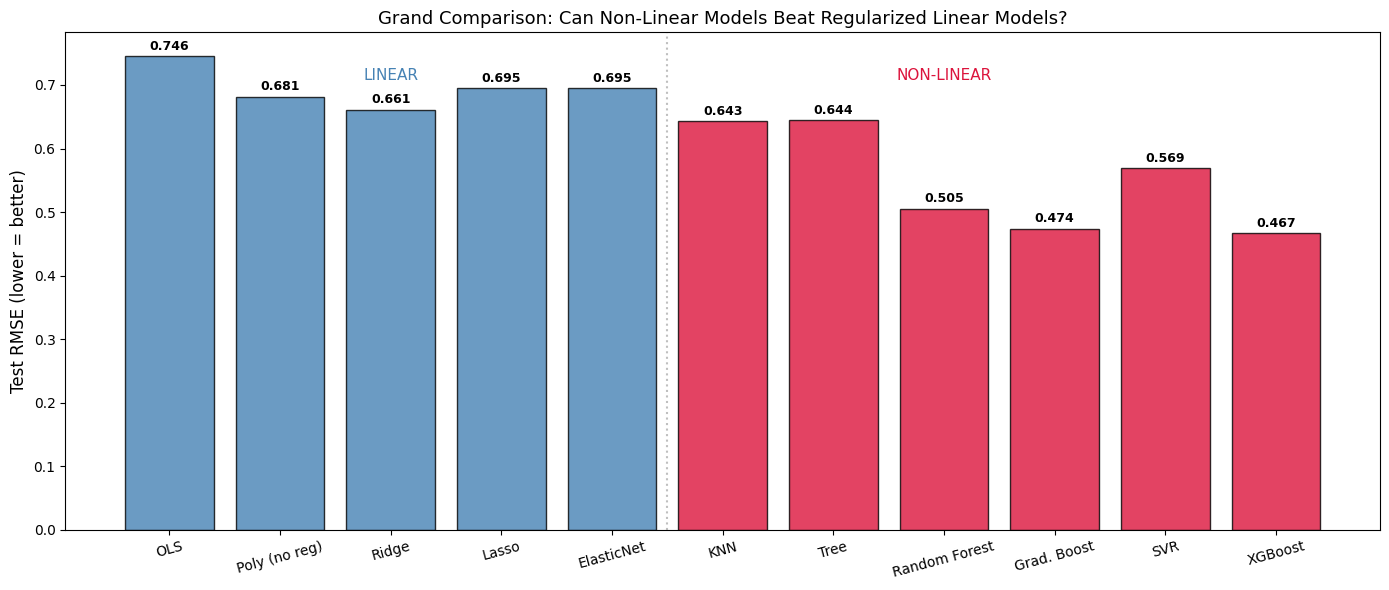


Overall Best Model: XGBoost (Test RMSE = 0.4665)
Best linear model: Ridge (Test RMSE = 0.6610)
Best non-linear model: XGBoost (Test RMSE = 0.4665)
Non-linear models are better by 29.42% (relative to linear).


In [34]:
# all model names in order (5 linear, then 6 non-linear)
all_names = ['OLS', 'Poly (no reg)', 'Ridge', 'Lasso', 'ElasticNet',
             'KNN', 'Tree', 'Random Forest', 'Grad. Boost', 'SVR', 'XGBoost']

# test RMSE for every model, in the same order
all_test_rmses = [
    rmse_test_baseline, rmse_test_poly, best_ridge_rmse, best_lasso_rmse, best_en_rmse,
    knn_results[best_k_val]['test'], tree_results[best_tree_depth]['test'],
    rf_rmse_te, gb_rmse_te, svr_rmse_te,
    xgb_rmse_te
]

# bar chart of test RMSE: blue for linear models, red for non-linear
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['steelblue']*5 + ['crimson']*6
bars = ax.bar(all_names, all_test_rmses, color=colors, alpha=0.8, edgecolor='black')

# write the RMSE value on top of each bar
for bar, val in zip(bars, all_test_rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
            ha='center', fontsize=9, fontweight='bold')

# vertical line and labels to split linear from non-linear
ax.axvline(x=4.5, color='gray', linestyle=':', alpha=0.5)
ax.text(2, max(all_test_rmses)*0.95, 'LINEAR', ha='center', fontsize=11, color='steelblue')
ax.text(7, max(all_test_rmses)*0.95, 'NON-LINEAR', ha='center', fontsize=11, color='crimson')

ax.set_ylabel('Test RMSE (lower = better)', fontsize=12)
ax.set_title('Grand Comparison: Can Non-Linear Models Beat Regularized Linear Models?', fontsize=13)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# find the overall best model
min_rmse_overall = np.min(all_test_rmses)
best_model_idx = np.argmin(all_test_rmses)
best_model_name = all_names[best_model_idx]

# best linear model (first 5)
linear_rmses = all_test_rmses[:5]
linear_names = all_names[:5]
best_linear_idx = np.argmin(linear_rmses)
best_linear_name = linear_names[best_linear_idx]
best_linear_rmse = linear_rmses[best_linear_idx]

# best non-linear model (the rest)
nonlinear_rmses = all_test_rmses[5:]
nonlinear_names = all_names[5:]
best_nonlinear_idx = np.argmin(nonlinear_rmses)
best_nonlinear_name = nonlinear_names[best_nonlinear_idx]
best_nonlinear_rmse = nonlinear_rmses[best_nonlinear_idx]

print(f"\nOverall Best Model: {best_model_name} (Test RMSE = {min_rmse_overall:.4f})")
print(f"Best linear model: {best_linear_name} (Test RMSE = {best_linear_rmse:.4f})")
print(f"Best non-linear model: {best_nonlinear_name} (Test RMSE = {best_nonlinear_rmse:.4f})")

# say which side won and by how much
if best_linear_rmse < best_nonlinear_rmse:
    improvement = ((best_nonlinear_rmse - best_linear_rmse) / best_nonlinear_rmse) * 100
    print(f"Linear models are better by {improvement:.2f}% (relative to non-linear).")
else:
    improvement = ((best_linear_rmse - best_nonlinear_rmse) / best_linear_rmse) * 100
    print(f"Non-linear models are better by {improvement:.2f}% (relative to linear).")

---
## Quick Reference: Key sklearn APIs

| Class | Module | Key Parameters | Notes |
|-------|--------|----------------|-------|
| `LinearRegression` | `sklearn.linear_model` | `fit_intercept` | No regularization (OLS) |
| `Ridge` | `sklearn.linear_model` | `alpha` | L2 penalty only |
| `Lasso` | `sklearn.linear_model` | `alpha`, `max_iter` | L1 penalty, sparse |
| `ElasticNet` | `sklearn.linear_model` | `alpha`, `l1_ratio`, `max_iter` | Combined L1+L2 |
| `RidgeCV` | `sklearn.linear_model` | `alphas` | Auto-tunes alpha |
| `LassoCV` | `sklearn.linear_model` | `alphas`, `cv` | Auto-tunes alpha |
| `ElasticNetCV` | `sklearn.linear_model` | `alphas`, `l1_ratio`, `cv` | Auto-tunes both |
| `PolynomialFeatures` | `sklearn.preprocessing` | `degree`, `include_bias` | Feature expansion |
| `StandardScaler` | `sklearn.preprocessing` | — | Z-score normalization |
| `KFold` | `sklearn.model_selection` | `n_splits`, `shuffle` | CV splits |
| `mean_squared_error` | `sklearn.metrics` | `y_true`, `y_pred` | MSE metric |
| `r2_score` | `sklearn.metrics` | `y_true`, `y_pred` | R² metric |

**Documentation:** https://scikit-learn.org/stable/modules/linear_model.html